In [1]:
!pip -q install numpy pandas matplotlib scikit-learn tqdm vector

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import glob
import gc

# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/main/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
vlf_files = list(glob.glob('./drive/MyDrive/Distributions/VLF/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900_yDM_1.npz')) + list(glob.glob('./drive/MyDrive/Distributions/VLF/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz'))
scalar_files = list(glob.glob('./drive/MyDrive/Distributions/Scalar/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz')) + list(glob.glob('./drive/MyDrive/Distributions/Scalar/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz'))
zp_files = list(glob.glob('./drive/MyDrive/Distributions/Zprime/mZp_2000.npz'))
sm_files = list(glob.glob('./drive/MyDrive/Distributions/SM/pp2ttbar/bias_article*/*.npz'))

print("--- File Discovery Check ---")
print(f"VLF files found:    {len(vlf_files)}")
print(f"Scalar files found: {len(scalar_files)}")
print(f"Zprime files found: {len(zp_files)}")
print(f"SM files found:     {len(sm_files)}\n")

KEYS_TO_SUM = ['xsec (pb)', 'n_events']

# Specify exactly which large event arrays to keep in memory.
# Everything else will be ignored, saving massive amounts of RAM.
KEYS_TO_KEEP = ['mTT', 'weights']

# Structure to hold lists of arrays, preventing iterative concatenation RAM spikes
raw_data = {
    'Scalar': {'arrays': {}, 'scalars': {}},
    'VLF':    {'arrays': {}, 'scalars': {}},
    'Zprime': {'arrays': {}, 'scalars': {}},
    'SM':     {'arrays': {}, 'scalars': {}}
}

# ------------------------------------------------------------
# Memory-Optimized Extraction Loop (List-Append Method)
# ------------------------------------------------------------
for f in vlf_files + scalar_files + zp_files + sm_files:
    aux = np.load(f, allow_pickle=True)

    model_name = aux['model']
    if isinstance(model_name, np.ndarray):
        model_name = model_name.item() if model_name.size == 1 else model_name[0]
    if isinstance(model_name, bytes):
        model_name = model_name.decode('utf-8')

    if model_name == '1-loop VLF':      target = raw_data['VLF']
    elif model_name == '1-loop Scalar': target = raw_data['Scalar']
    elif model_name == 'Z prime':       target = raw_data['Zprime']
    elif model_name == 'SM':            target = raw_data['SM']
    else:
        print(f'Model not found: {model_name}')
        aux.close()
        continue

    for key in aux.files:
        val = aux[key]
        if key in KEYS_TO_SUM:
            if key not in target['scalars']: target['scalars'][key] = 0.0
            target['scalars'][key] += float(val.item())
        elif val.ndim == 0 or val.size == 1:
            if not isinstance(val.item(), dict): # Drop nested dicts
                target['scalars'][key] = val.item()
        else:
            if key not in KEYS_TO_KEEP:
                continue

            if key not in target['arrays']: target['arrays'][key] = []
            target['arrays'][key].append(val[:]) # Append array to list

    aux.close()

# Concatenate each list of arrays exactly once
for model in raw_data:
    for key, list_of_arrays in raw_data[model]['arrays'].items():
        if list_of_arrays:
            raw_data[model]['arrays'][key] = np.concatenate(list_of_arrays, axis=0)

# ------------------------------------------------------------
# Post-Processing: Weights & Renaming
# ------------------------------------------------------------
sm_file_count = len(sm_files)
if sm_file_count > 0 and 'weights' in raw_data['SM']['arrays']:
    print(f"Applying SM scaling: dividing weights by {sm_file_count}")
    raw_data['SM']['arrays']['weights'] /= sm_file_count
    if 'xsec (pb)' in raw_data['SM']['scalars']:
        raw_data['SM']['scalars']['xsec (pb)'] /= sm_file_count

y_DM = {'VLF': 6.0, 'Scalar': 1.268000e+01}

for model_name, data in raw_data.items():
    arrs = data['arrays']
    if not arrs: continue

    factor = y_DM.get(model_name, 1.0)**2
    if factor != 1.0 and 'weights' in arrs:
        arrs['weights'] *= factor

    # Rename securely
    if 'weights' in arrs: arrs['weight'] = arrs.pop('weights')
    if 'mTT' in arrs:     arrs['m_tt'] = arrs.pop('mTT')

# ------------------------------------------------------------
# Pure NumPy Assembly
# ------------------------------------------------------------
# Get the length of events per model
l_s  = len(raw_data['Scalar']['arrays'].get('weight', []))
l_v  = len(raw_data['VLF']['arrays'].get('weight', []))
l_z  = len(raw_data['Zprime']['arrays'].get('weight', []))
l_sm = len(raw_data['SM']['arrays'].get('weight', []))

final_dict = {}

# Build the exact label structure requested: BSM + SM(as BSM) + Pure SM
labels_list = []
if l_s > 0:  labels_list.extend([np.full(l_s, 'Scalar'), np.full(l_sm, 'Scalar')])
if l_v > 0:  labels_list.extend([np.full(l_v, 'VLF'),    np.full(l_sm, 'VLF')])
if l_z > 0:  labels_list.extend([np.full(l_z, 'Zprime'), np.full(l_sm, 'Zprime')])
if l_sm > 0: labels_list.append(np.full(l_sm, 'SM'))

if labels_list:
    final_dict['label'] = np.concatenate(labels_list)

# Safely stack all matching physical array variables across the models
for key in raw_data['SM']['arrays'].keys():
    arrs_to_concat = []

    if l_s > 0:  arrs_to_concat.extend([raw_data['Scalar']['arrays'][key], raw_data['SM']['arrays'][key]])
    if l_v > 0:  arrs_to_concat.extend([raw_data['VLF']['arrays'][key],    raw_data['SM']['arrays'][key]])
    if l_z > 0:  arrs_to_concat.extend([raw_data['Zprime']['arrays'][key], raw_data['SM']['arrays'][key]])
    if l_sm > 0: arrs_to_concat.append(raw_data['SM']['arrays'][key])

    if arrs_to_concat:
        final_dict[key] = np.concatenate(arrs_to_concat, axis=0)

# Build the DataFrame exactly once from the finalized flat dictionary
df_bsm = pd.DataFrame(final_dict)

# Recreate the isolated pure SM DataFrame you need for template building
df_sm = pd.DataFrame(raw_data['SM']['arrays'])
if not df_sm.empty:
    df_sm['label'] = 'SM'

# Aggressively delete the raw_data dictionary to free RAM immediately
del raw_data, final_dict, labels_list
gc.collect()


--- File Discovery Check ---
VLF files found:    2
Scalar files found: 2
Zprime files found: 1
SM files found:     8

Applying SM scaling: dividing weights by 8


327

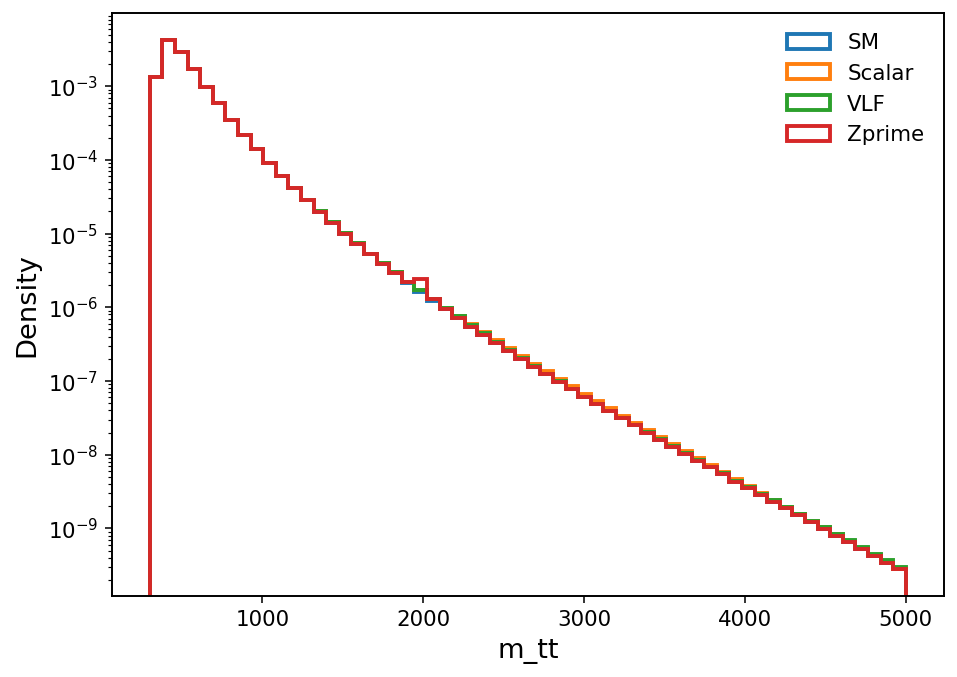

In [4]:
# Testing if the distribution looks like the expected one
def weighted_hist_by_label(df, var, bins=60, rng=None, density=False):
    """Plots superimposed 1D distributions for all specific labels in a dataframe."""

    label_col = "label" if "label" in df.columns else "model"
    weight_col = "weight" if "weight" in df.columns else "w_norm"
    target_models = ["Scalar", "VLF", "Zprime", 'SM']

    plt.figure(figsize=(7, 5))


    df_clean = df[[label_col, var, weight_col]].replace([np.inf, -np.inf], np.nan).dropna()


    for lab, sub in df_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_models:
            continue

        # Extract pure numpy arrays for matplotlib
        x = sub[var].values
        w = np.abs(sub[weight_col].values)

        plt.hist(x, bins=bins, range=rng, weights=w,
                 histtype="step", linewidth=2, label=lab_str, density=density)

    plt.xlabel(var)
    plt.ylabel("Density" if density else "Weighted Counts")
    plt.legend(loc="best")
    plt.yscale('log')
    plt.tight_layout()
    plt.show()
# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [
    ("m_tt", (300, 5000)),
    #("pt_tt", (0, 800)),
    #("abs_cos_theta_star", (0, 1)),
    #("abs_delta_y", (0, 5)),
    #("ptj1", (0, 500)),
]

for v, rng in observables:
    # We no longer need to pass weight_col, it will find it automatically
    weighted_hist_by_label(df_bsm, v, bins=60, rng=rng, density=True)

In [5]:
# ------------------------------------------------------------
# m_cut Scan Configuration
# ------------------------------------------------------------
labels = ["Scalar", "VLF", "Zprime"]
mcuts = [500, 800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 3000]
mcut_max = 4_500
bin_width = 100.0
L_target = 500.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# ------------------------------------------------------------
# Luminosity Scan Configuration (Notebook)
# ------------------------------------------------------------
labels = ["Scalar", "VLF", "Zprime"]
lumi_targets = [300., 500., 1000., 1500., 2000., 2500., 3000.]
eps_values = [0.0, 0.02, 0.05, 0.10]


# ------------------------------------------------------------
# Data Extraction
# ------------------------------------------------------------
var = "m_tt"  # Variable of the distributions

# Clean the DataFrames
df_sm_clean = df_sm[[var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_sm_clean = df_sm_clean[df_sm_clean[var] > 0]

df_hyp_clean = df_bsm[["label", var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_clean = df_hyp_clean[df_hyp_clean[var] > 0]

# Extract into pure NumPy dictionaries
sm_data = {
    "x": df_sm_clean[var].values,
    "w": df_sm_clean["weight"].values
}

bsm_data = {}
for lab, sub in df_hyp_clean.groupby("label"):
    lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
    if lab_str in labels:
        bsm_data[lab_str] = {
            "x": sub[var].values,
            "w": sub["weight"].values
        }
# ------------------------------------------------------------
# Load the m cut and luminosity scan data frames
# ------------------------------------------------------------
# Run the scan once to calculate both Shape and Falloff metrics
df_mcut = hp.run_fast_mcut_scan(sm_data, bsm_data, labels, mcuts=mcuts,
                                mcut_max=mcut_max, bin_width=bin_width,
                                L_target=L_target, eps_values=eps_values)

# Run the scan once to calculate both Shape and Falloff metrics but for luminosity
df_lumi = hp.run_fast_lumi_scan(sm_data, bsm_data, labels, target_mcut=1800, mcut_max=4500,
                                bin_width=100.0, lumi_targets=lumi_targets, eps_values=eps_values)


# Shape Analysis with statistics

$$Z_{\rm syst}^2
\;\approx\;
\sum_k
\frac{\left(n_k^{(A)}-n_k^{(B)}\right)^2}
{n_k^{\rm ref}+\left(\varepsilon\, n_k^{\rm ref}\right)^2} $$




## The below cell is the Asimov significance in function of the cut in $m_{t\bar{t}}$

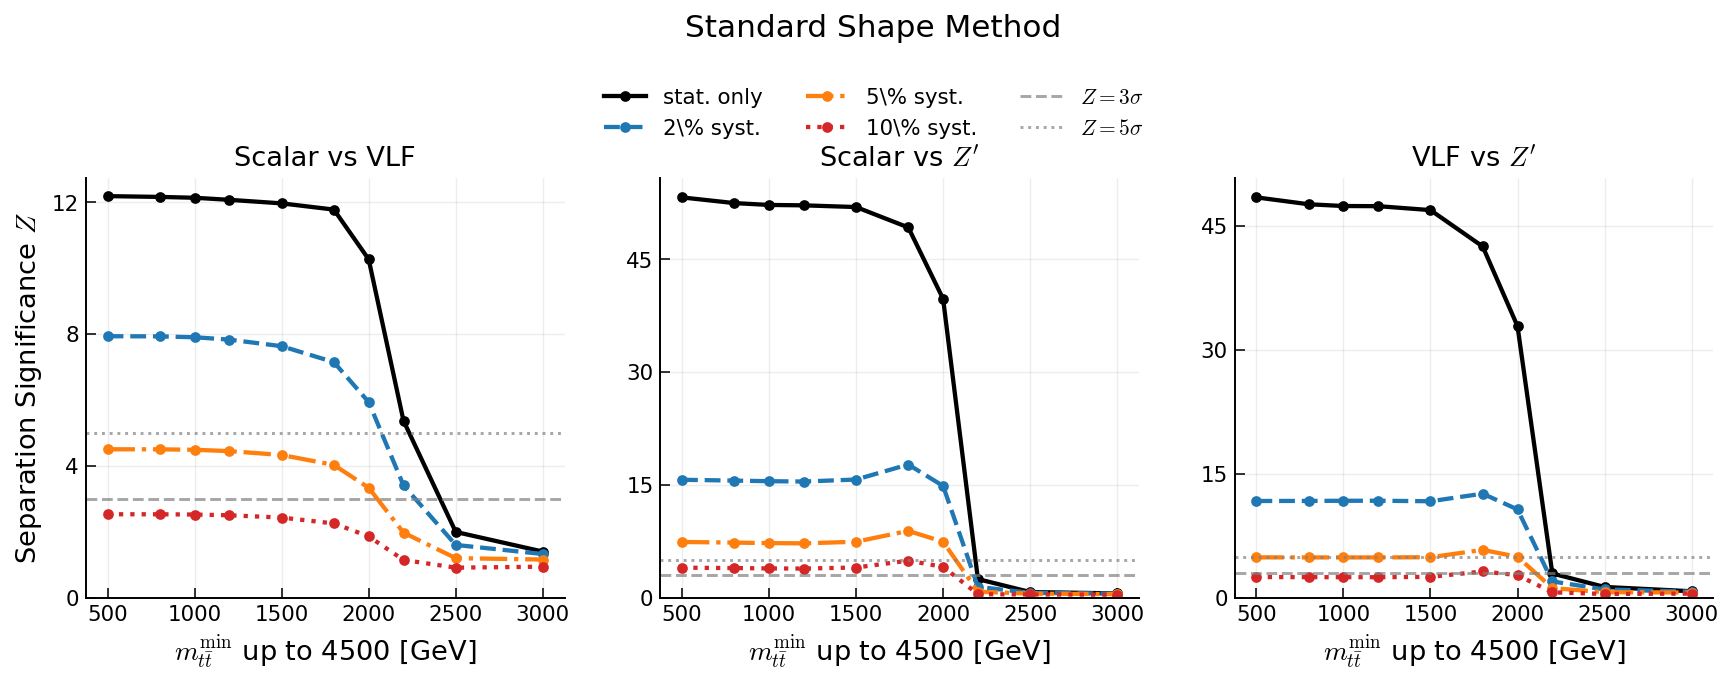

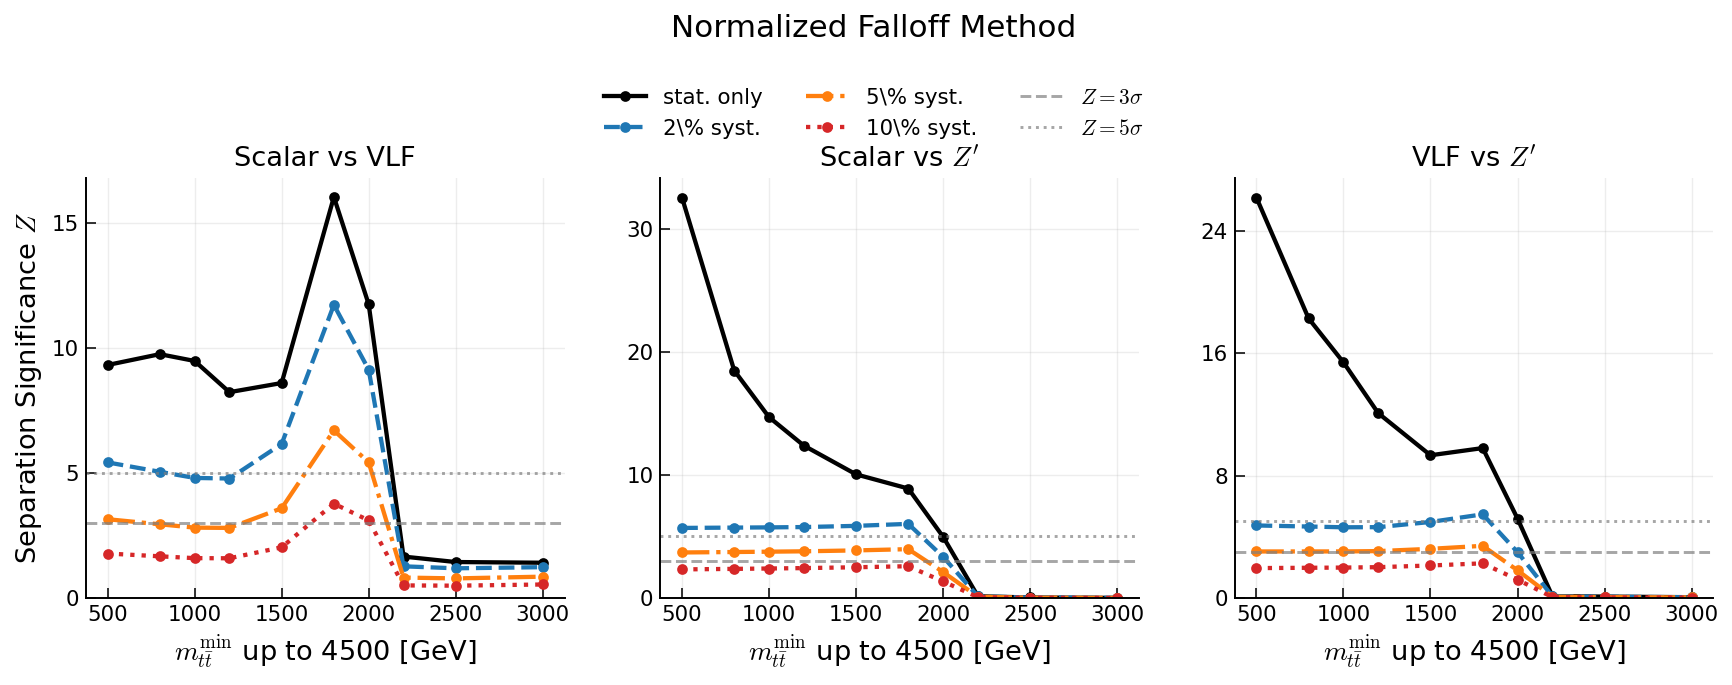

In [6]:


outdir = Path("paper_plots_systematics")
outdir.mkdir(parents=True, exist_ok=True)


# Plot Standard Shape Method
hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="sh",
                       outfile=outdir / "syst_grid_mcut_shape.pdf")

# Plot Normalized Falloff Method
hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="fa",
                       outfile=outdir / "syst_grid_mcut_falloff.pdf")

## The below cell is the Asimov significance in function of the Luminosity in $m_{t\bar{t}}$

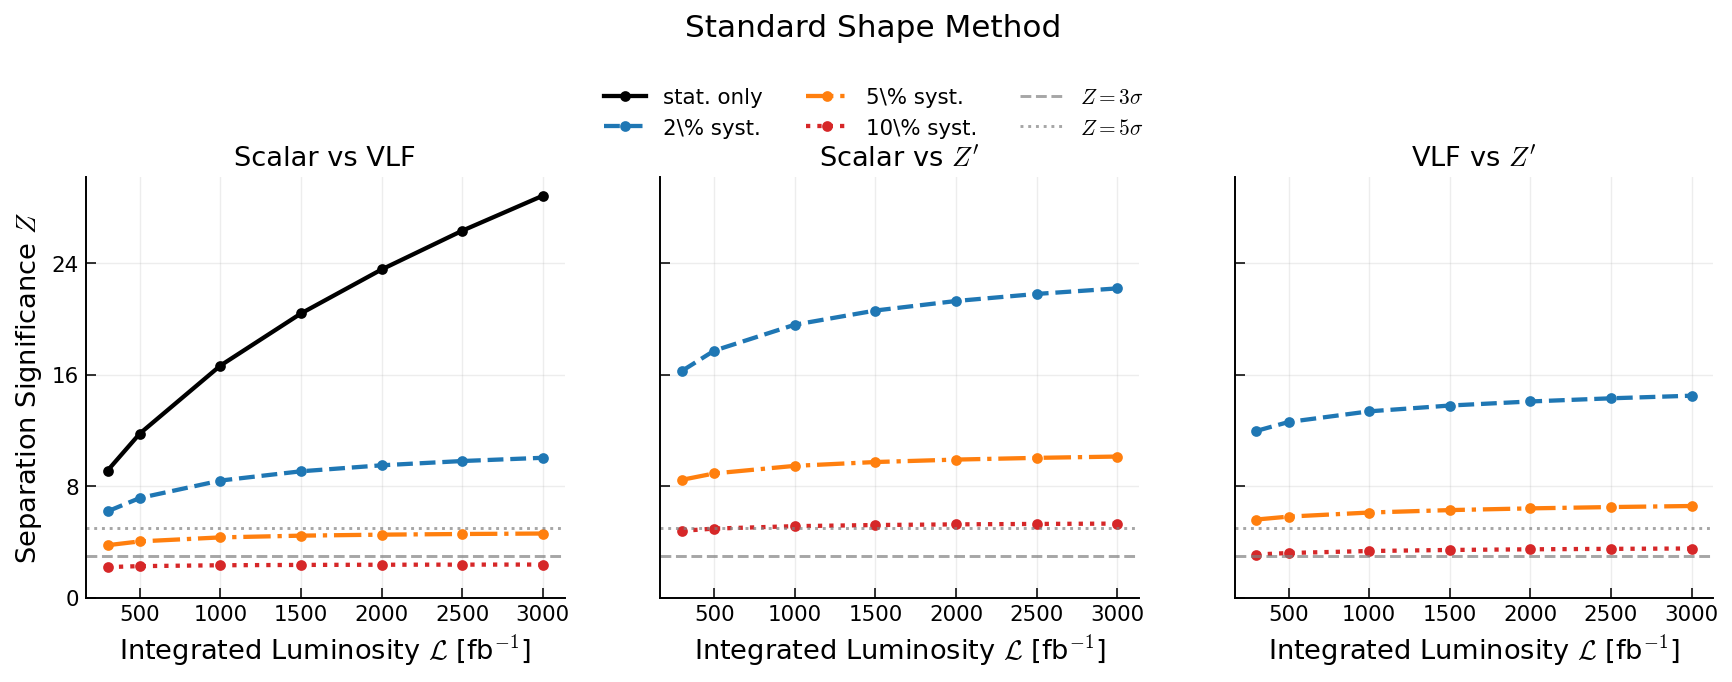

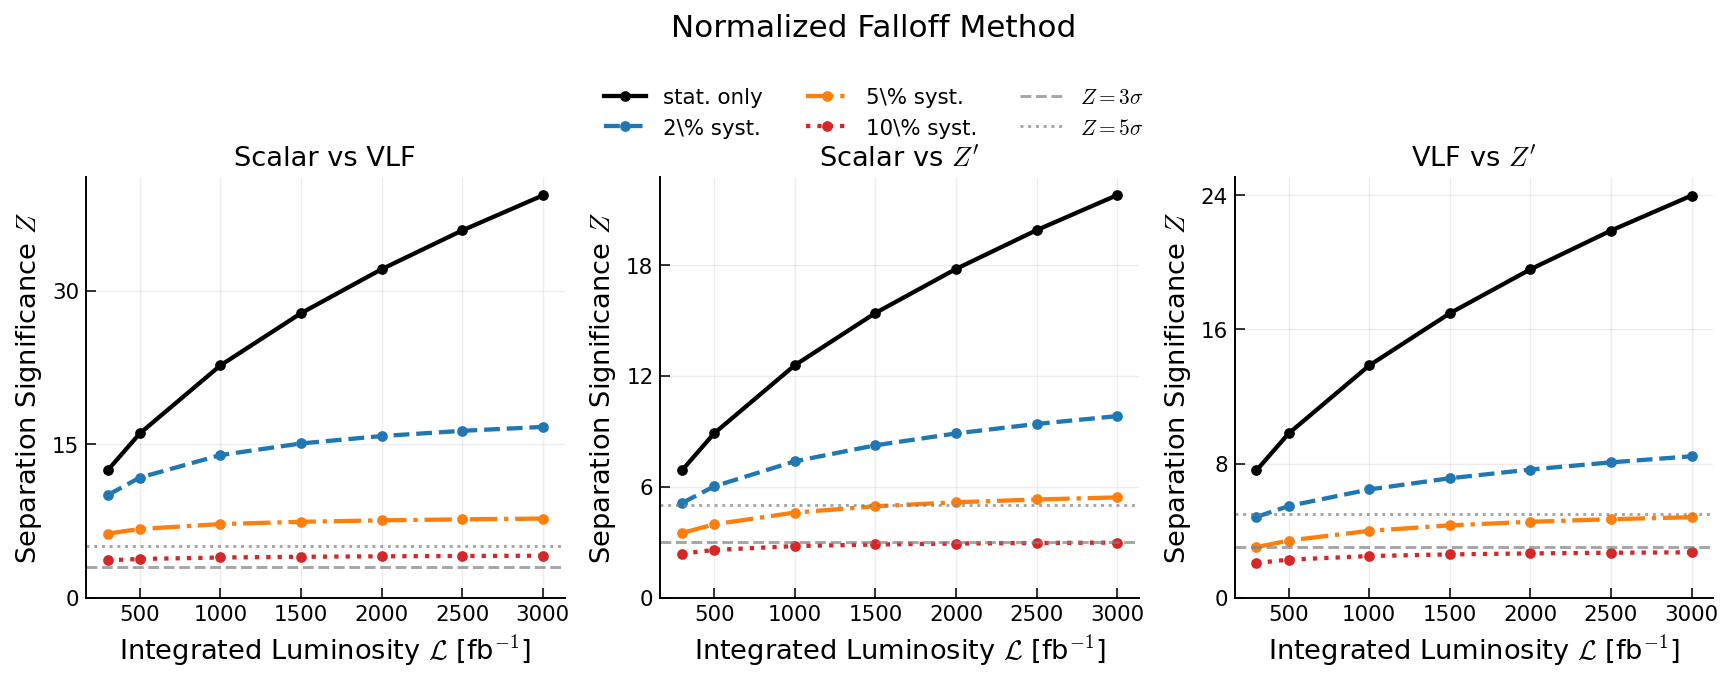

In [7]:

outdir = Path("paper_plots_systematics")



# Plot Standard Shape Method
hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="sh",
                       outfile=outdir / "syst_grid_lumi_shape.pdf")

# Plot Falloff Method (excluding stats-only line, just as an example)
hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="fa", excl_stats=False, shareY=False,
                       outfile=outdir / "syst_grid_lumi_falloff_excl_stats.pdf")

# Fallof Analysis

$$Z_{\rm falloff}^2
\;\approx\;
\sum_k
\frac{\left(N\,\widehat{\Delta}_i(k)-N\,\widehat{\Delta}_j(k)\right)^2}
{\sigma_{\rm ref}^2},
\qquad
n_k^{\rm ref}=\frac{N}{2}\left(|\widehat{\Delta}_i(k)|+|\widehat{\Delta}_j(k)|\right)$$

To compute $\sigma_{\rm ref}^2$, notice that since:

$$\Delta_i^{(m_{t\bar t}^{\min})}(k) =
\frac{n_{i,k}-n_{{\rm SM},k}}{n_{{\rm SM},k}} $$

The variance of $\Delta_i^{(m_{t\bar t}^{\min})}(k)$ is:

$$\sigma_\Delta^2 = \frac{n_{i,k}}{n_{SM,k}^2} + \frac{n_{i,k}^2\varepsilon^2}{ n_{SM,k}^2} = \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right)$$

To compute $\widehat{\Delta}_i^{(m_{t\bar t}^{\min})}(k)$ we used:

$$\widehat{\Delta}_i^{(m_{t\bar t}^{\min})}(k) = \frac{\Delta_i^{(m_{t\bar t}^{\min})}(k)}
{\sum_\ell \left|\Delta_i^{(m_{t\bar t}^{\min})}(\ell)\right|}$$

To simplify the notation, consider $S = \sum_\ell \left|\Delta_i^{(m_{t\bar t}^{\min})}(\ell)\right|$.

Therefore, the variance of $\widehat{\Delta}_i^{(m_{t\bar t}^{\min})}(k)$ is:

$$\sigma_{\hat{\Delta}_i}^2 = \sum_j \left( \frac{\partial \widehat{\Delta}_i}{\partial \Delta_j} \right)^2 \sigma_{\Delta_j}^2 = \left( \frac{\partial \widehat{\Delta}_i}{\partial \Delta_i} \right)^2 \sigma_{\Delta_i}^2 + \sum_{j\neq i} \left( \frac{\partial \widehat{\Delta}_i}{\partial \Delta_j} \right)^2 \sigma_{\Delta_j}^2$$

 The derivative with respect to a different bin ($j \neq i$):

 $$\frac{\partial \widehat{\Delta}_i}{\partial \Delta_j} = \Delta_k \frac{\partial}{\partial \Delta_j} (S^{-1}) = -\frac{\Delta_i}{S^2} \frac{\partial S}{\partial \Delta_j} = -\frac{\Delta_i \text{sgn}(\Delta_j)}{S^2}$$
$$\implies \left( \frac{\partial \widehat{\Delta}_k}{\partial \Delta_j} \right)^2 = \frac{\Delta_k^2 \text{sgn}^2(\Delta_j)}{S^4} = \frac{\Delta_k^2}{S^4}$$(
  
   The derivative with respect to the same bin ($j = i$):
   
   $$\frac{\partial \widehat{\Delta}_i}{\partial \Delta_i} = \frac{1 \cdot S - \Delta_i \cdot \text{sgn}(\Delta_i)}{S^2} = \frac{1}{S} - \frac{|\Delta_i|}{S^2}$$
   $$\implies \left( \frac{\partial \widehat{\Delta}_i}{\partial \Delta_i} \right)^2 = \frac{1}{S^2} - \frac{2|\Delta_i|}{S^3} + \frac{\Delta_i^2}{S^4}$$
   
   Combining the Terms:
   
   $$\sigma_{\hat{\Delta}_i}^2 = \left[ \frac{1}{S^2} - \frac{2|\Delta_i|}{S^3} + \frac{\Delta_i^2}{S^4} \right] \sigma_{\Delta_i}^2 + \sum_{j \neq i} \left[ \frac{\Delta_i^2}{S^4} \right] \sigma_{\Delta_j}^2$$
   $$\sigma_{\hat{\Delta}_i}^2 = \left[ \frac{1}{S^2} - \frac{2|\Delta_i|}{S^3}  \right] \sigma_{\Delta_i}^2 + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \sigma_{\Delta_j}^2$$
   $$\sigma_{\hat{\Delta}_{i,k}}^2 = \left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{n_{i,j}}{n_{SM,j}^2}\left(1 + n_{i,j}\varepsilon^2\right)$$

For a given luminosity $\mathcal{L}$, $n_{i,k} = \mathcal{L} x_{i,k}$:
$$\sigma_{\hat{\Delta}_{i,k}}^2 = \left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{x_{i,k}}{x_{SM,k}^2}\left(\frac{1}{\mathcal{L}} + x_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{x_{i,j}}{x_{SM,j}^2}\left(\frac{1}{\mathcal{L}} + x_{i,j}\varepsilon^2\right)$$


Recall that the definition of $n_{ref}(k)$ is:

$$n_k^{\rm ref}=\frac{N}{2}\left(|\widehat{\Delta}_i(k)|+|\widehat{\Delta}_j(k)|\right)$$

Therefore:
$$\sigma_{n_k^{\rm ref}} = \sqrt{\left(\frac{\partial n_k^{\rm ref}}{\partial \widehat{\Delta}_i(k)}\right)^2\sigma_{\widehat{\Delta}_i(k)}^2 +\left(\frac{\partial n_k^{\rm ref}}{\partial \widehat{\Delta}_j(k)}\right)^2 \sigma_{\widehat{\Delta}_j(k)}^2}$$
$$\sigma_{n_k^{\rm ref}} = \frac{N}{2}\sqrt{\left(\frac{\partial \vert\widehat{\Delta}_i(k)\vert}{\partial \widehat{\Delta}_i(k)}\right)^2 \sigma_{\widehat{\Delta}_i(k)}^2 + \left(\frac{\partial \vert\widehat{\Delta}_j(k)\vert}{\partial \widehat{\Delta}_j(k)}\right)^2 \sigma_{\widehat{\Delta}_j(k)}^2}$$
$$\sigma_{n_k^{\rm ref}} = \frac{N}{2}\sqrt{ \sigma_{\widehat{\Delta}_i(k)}^2 + \sigma_{\widehat{\Delta}_j(k)}^2}$$

Notice that:

$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} = \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{n_{i,j}}{n_{SM,j}^2}\left(1 + n_{i,j}\varepsilon^2\right)}{n_{ref} + \varepsilon^2 n_{ref}}$$
$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} \approx \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{n_{i,j}}{n_{SM,j}^2}\left(1 + n_{i,j}\varepsilon^2\right)}{n^{ref}_{shape}+ \varepsilon^2 n^{ref}_{shape}}$$
$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} \approx \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{n_{i,j}}{n_{SM,j}^2}\left(1 + n_{i,j}\varepsilon^2\right)}{ \varepsilon^2 (n^{ref}_{shape})^2}$$
$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} \approx \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{x_{i,k}}{x_{SM,k}^2}\left(\frac{1}{\mathcal{L}\varepsilon^2} + x_{i,k}\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{x_{i,j}}{x_{SM,j}^2}\left(\frac{1}{\mathcal{L}\varepsilon^2} + x_{i,j}\right)}{ \mathcal{L}^2(x^{ref}_{shape})^2}$$
$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} \approx \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{x_{i,k}}{\mathcal{L}^2x_{SM,k}^2}\left(\frac{1}{\mathcal{L}\varepsilon^2} + x_{i,k}\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{x_{i,j}}{\mathcal{L}^2x_{SM,j}^2}\left(\frac{1}{\mathcal{L}\varepsilon^2} + x_{i,j}\right)}{ (x^{ref}_{shape})^2}$$

## The cell below contains the Asimov significance as a function of the $m_{t\bar{t}}$ cut

# Analysis on the improvement Ratio $Z_{{\rm falloff}}/Z_{{\rm shape}}$

In [8]:
#Loading the scans
# ------------------------------------------------------------
# Global Configuration
# ------------------------------------------------------------
labels = ["Scalar", "VLF", "Zprime"]

# Grid Variables
mcuts = [1000, 1200, 1500, 1800, 2000, 2200, 2500, 3000]
lumi_targets = [300., 500., 1000., 1500., 2000., 2500., 3000.]
eps_values = [0.0, 0.02, 0.05, 0.10]

# Fixed Constants
bin_width = 100.0 # GeV
mcut_max = 4_500
L_target = 500.0 # fb^{-1} (Fixed baseline for the m_cut scan)
target_mcut = 1800 # GeV (Fixed baseline for the lumi scan)
bin_offset = 0.0 # For tests only

outdir = Path("separation_analysis_results")
outdir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Mass Cut Ratio Scan
# ------------------------------------------------------------
df_mcut_scan = hp.run_fast_mcut_scan(sm_data, bsm_data, labels, mcuts=mcuts,
                                     mcut_max=mcut_max, bin_width=bin_width,
                                     L_target=L_target, eps_values=eps_values,
                                     bin_offset=bin_offset)




# ------------------------------------------------------------
# Luminosity Ratio Scan
# ------------------------------------------------------------
df_lumi_scan = hp.run_fast_lumi_scan(sm_data, bsm_data, labels, target_mcut=target_mcut,
                                     mcut_max=mcut_max, bin_width=bin_width,
                                     lumi_targets=lumi_targets, eps_values=eps_values,
                                     bin_offset=bin_offset)



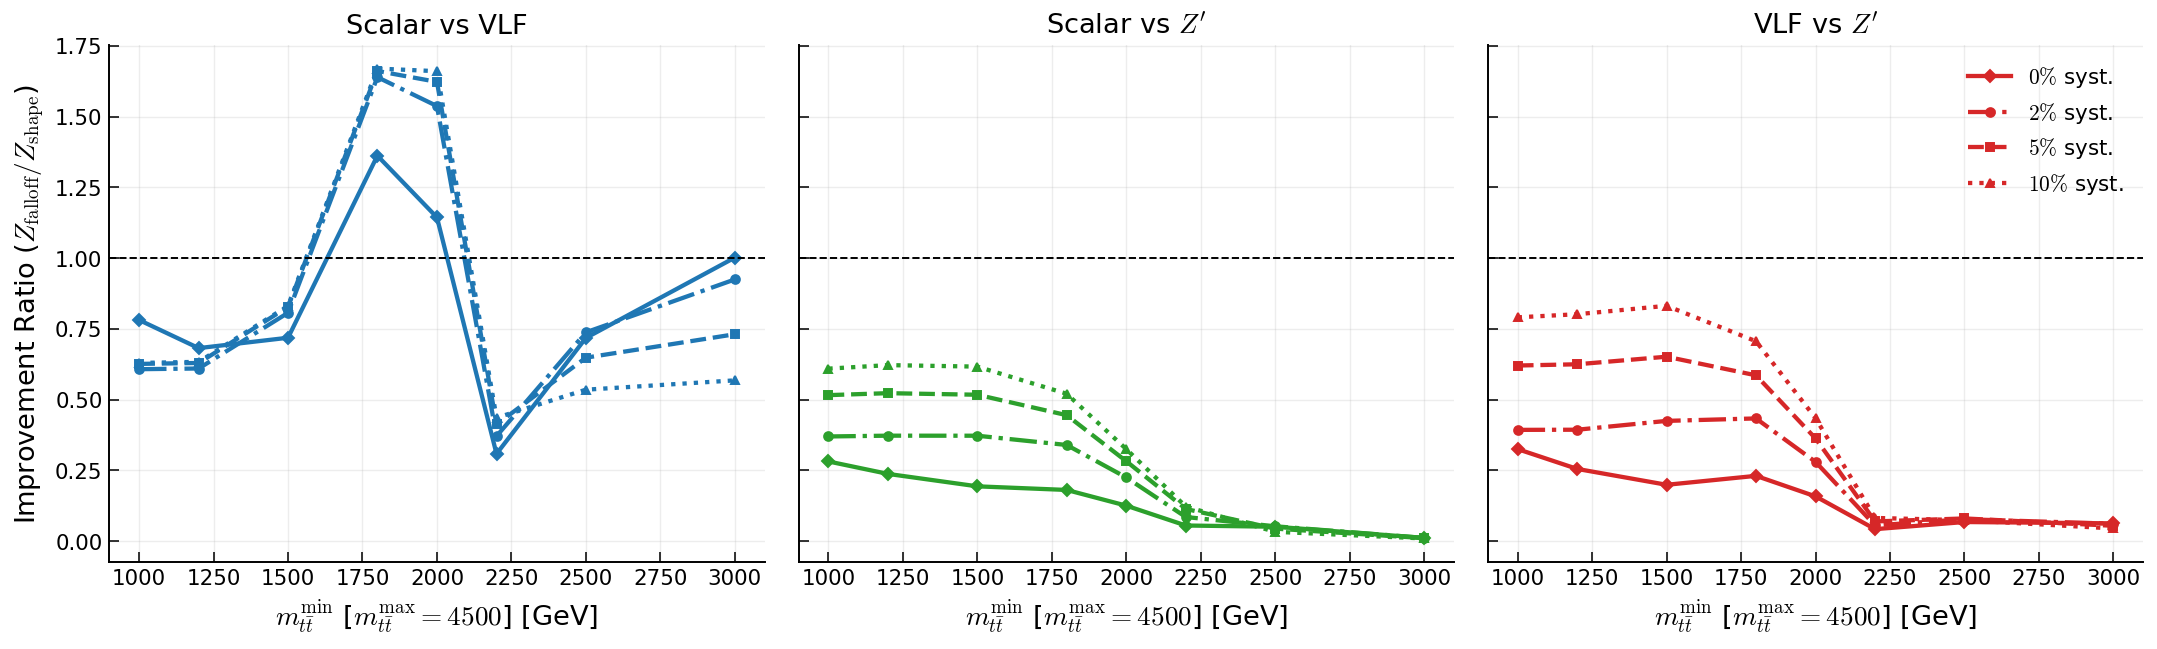

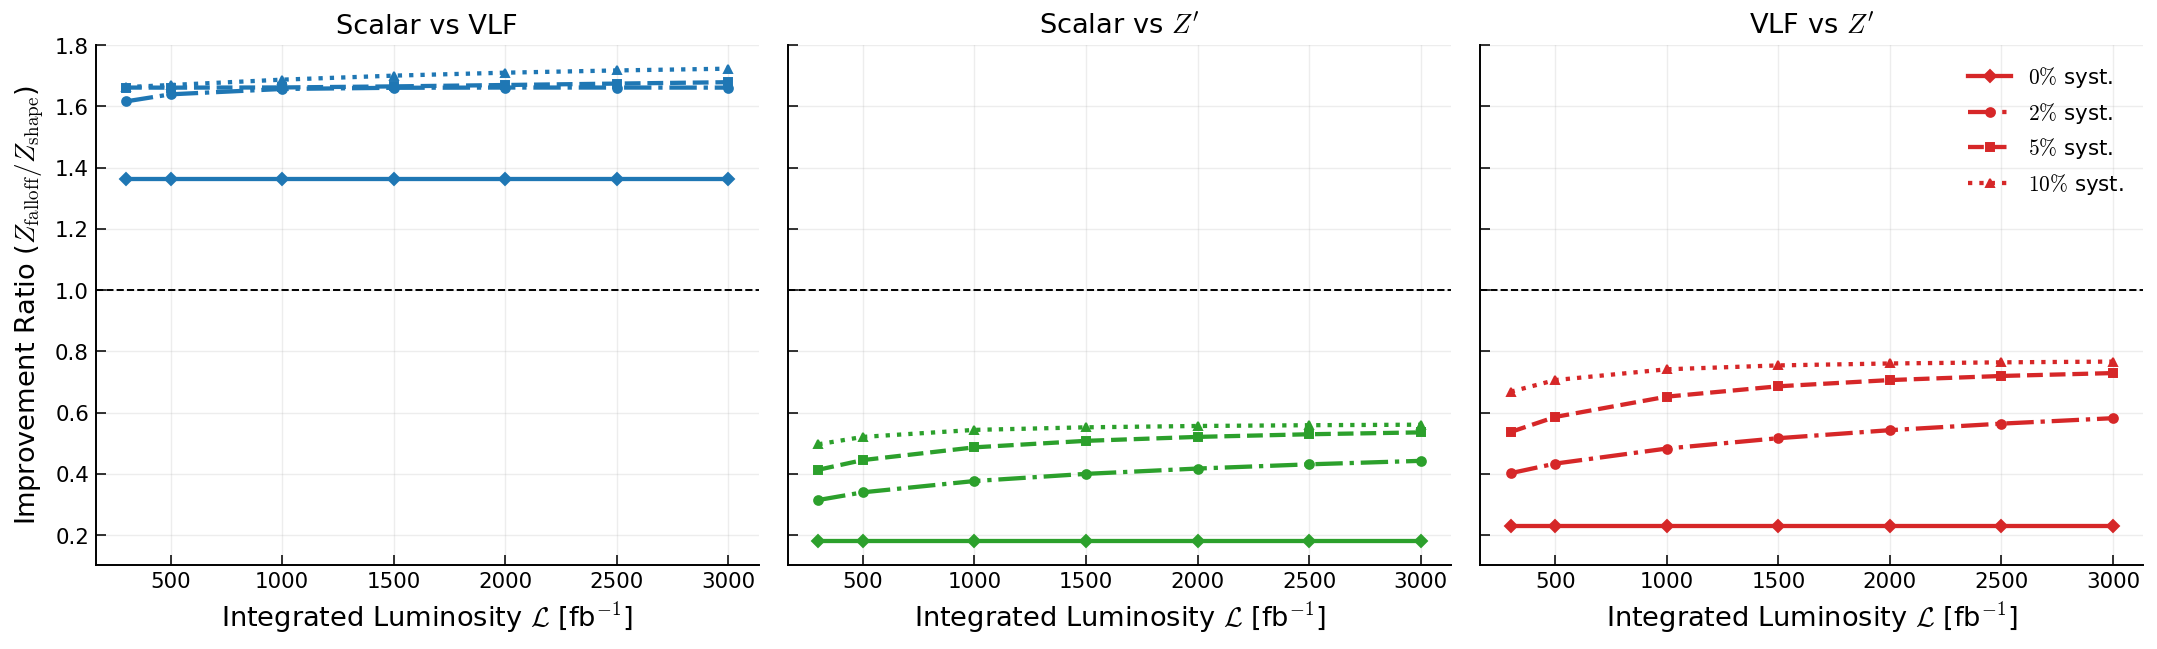

In [9]:
#Plot the mcut scan
hp.plot_ratio_pairwise(df_mcut_scan, mcut_max, eps_values,
                       outfile=outdir / f"ratio_pairwise_mcut_L{int(L_target)}.pdf")

#Plot the luminosity scan
hp.plot_ratio_pairwise_lumi(df_lumi_scan, target_mcut, eps_values,
                            outfile=outdir / f"ratio_pairwise_lumi_mcut{target_mcut}.pdf")

# Why does worse systematical errors lead to better performance of the Fallof in relation to the shape

## The next cell contains the plots of the Fallof numerator and denominator bin-by-bin contribution, the Shape numerator and denominator bin-by-bin contribution the ratios of Falloff and shape numerators and denominators

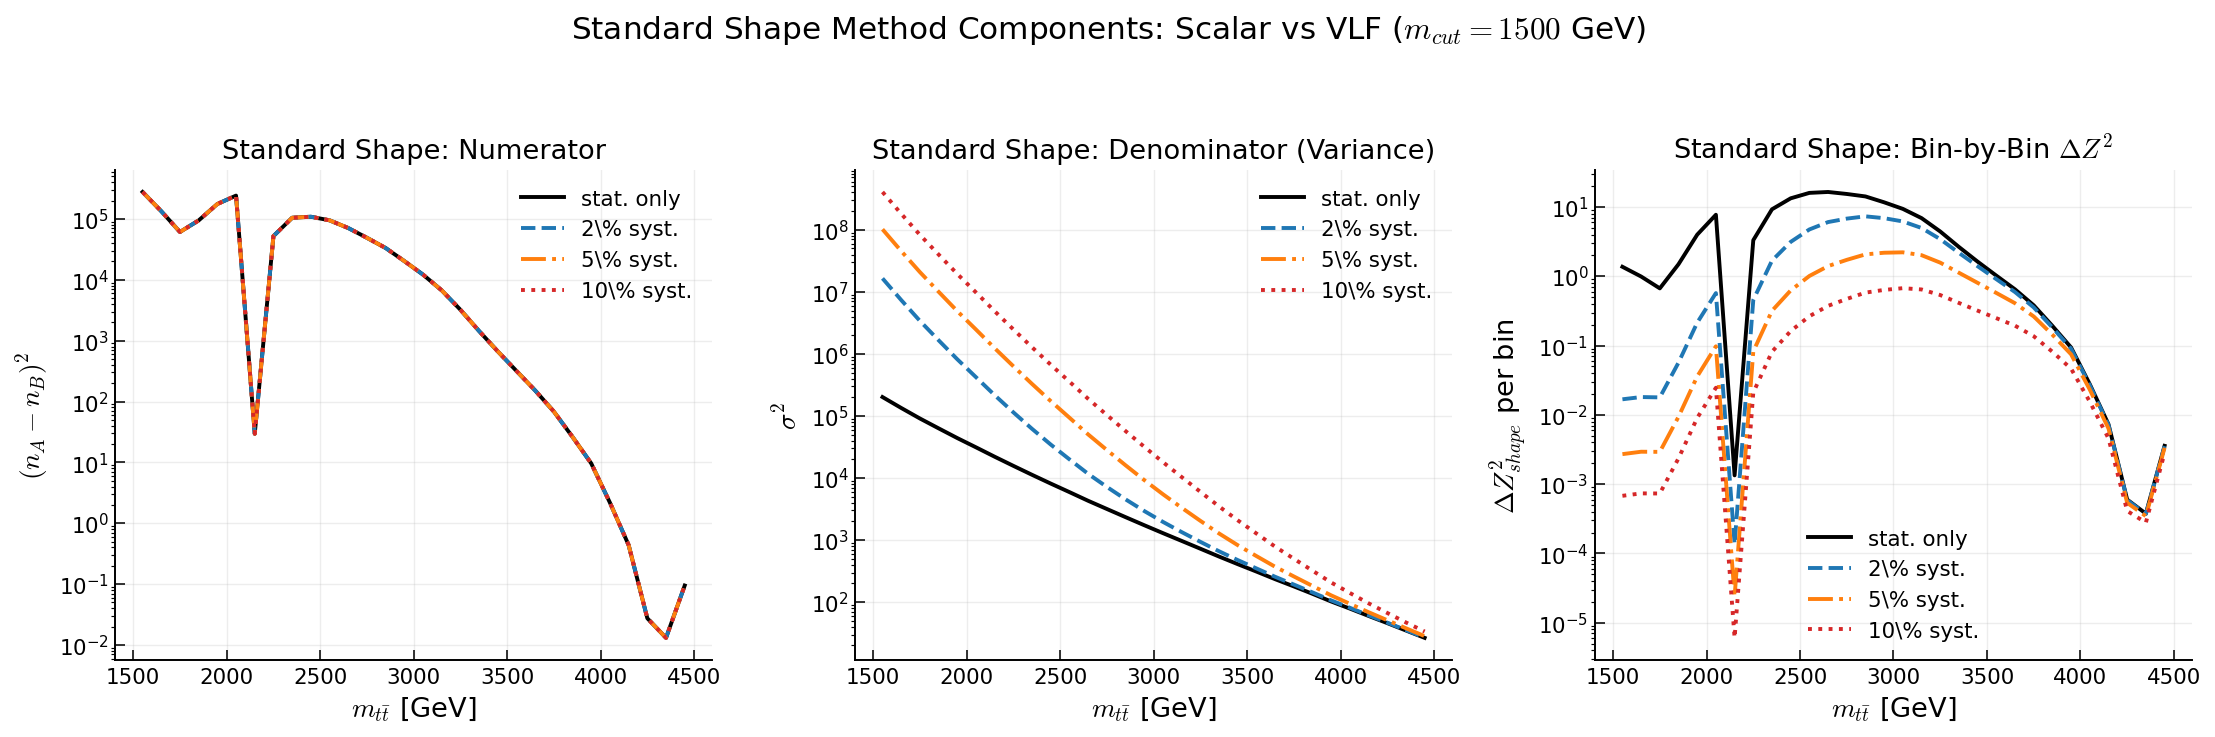

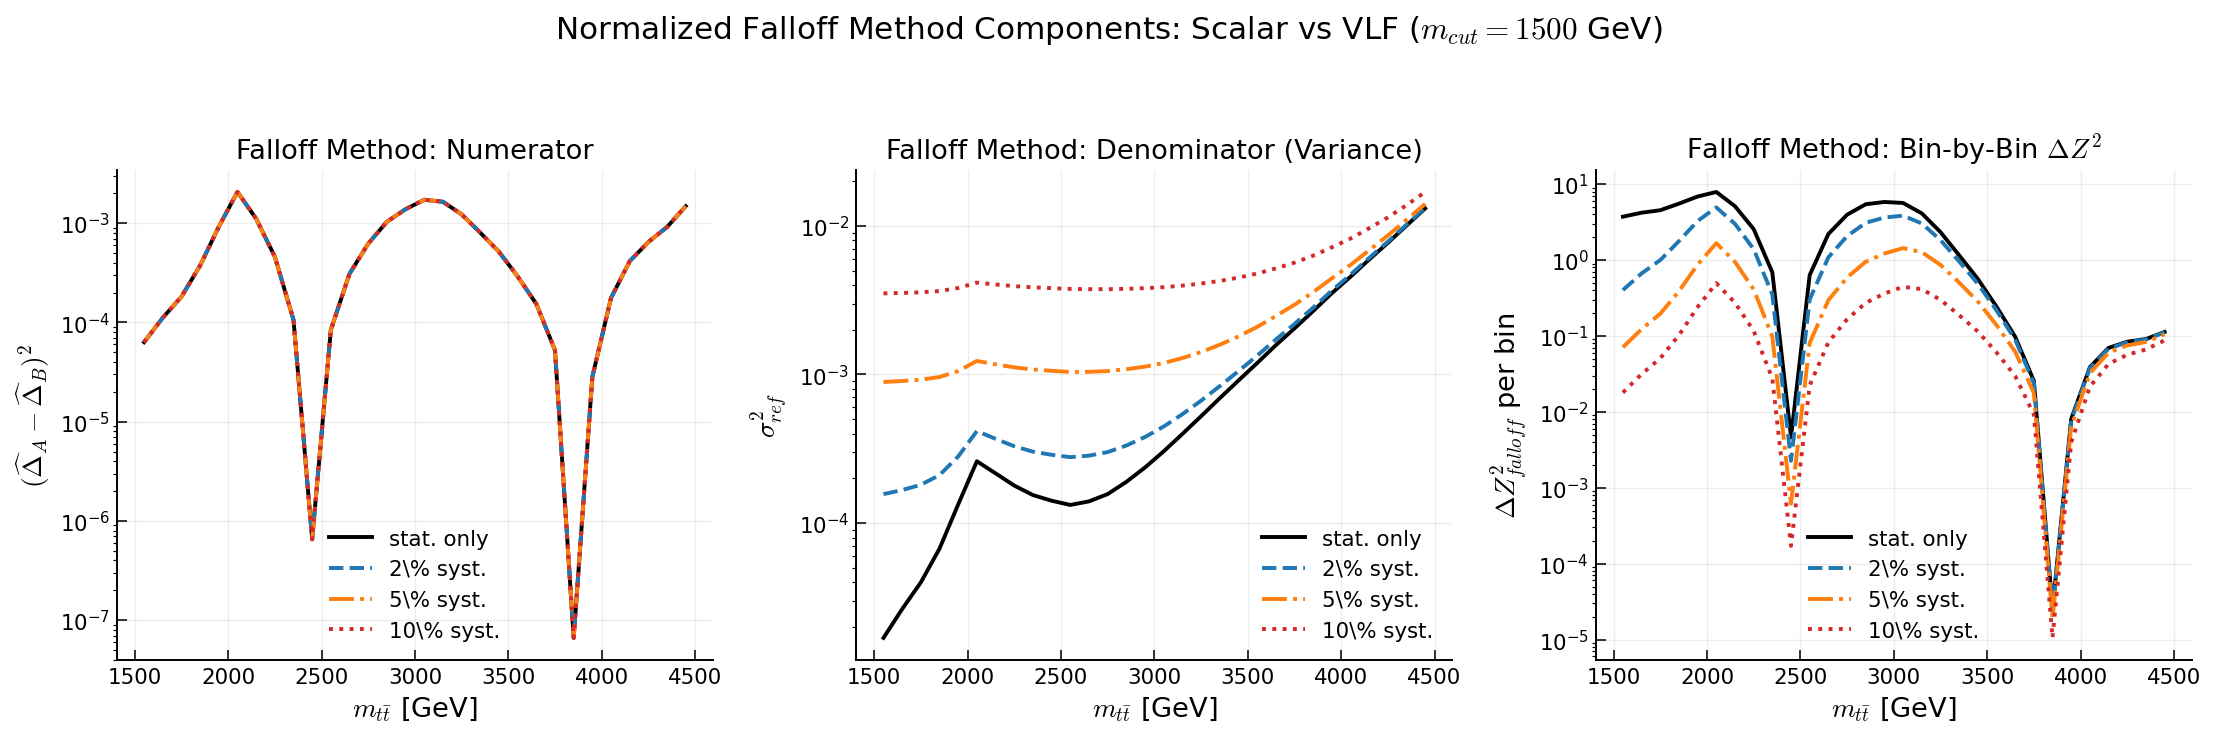

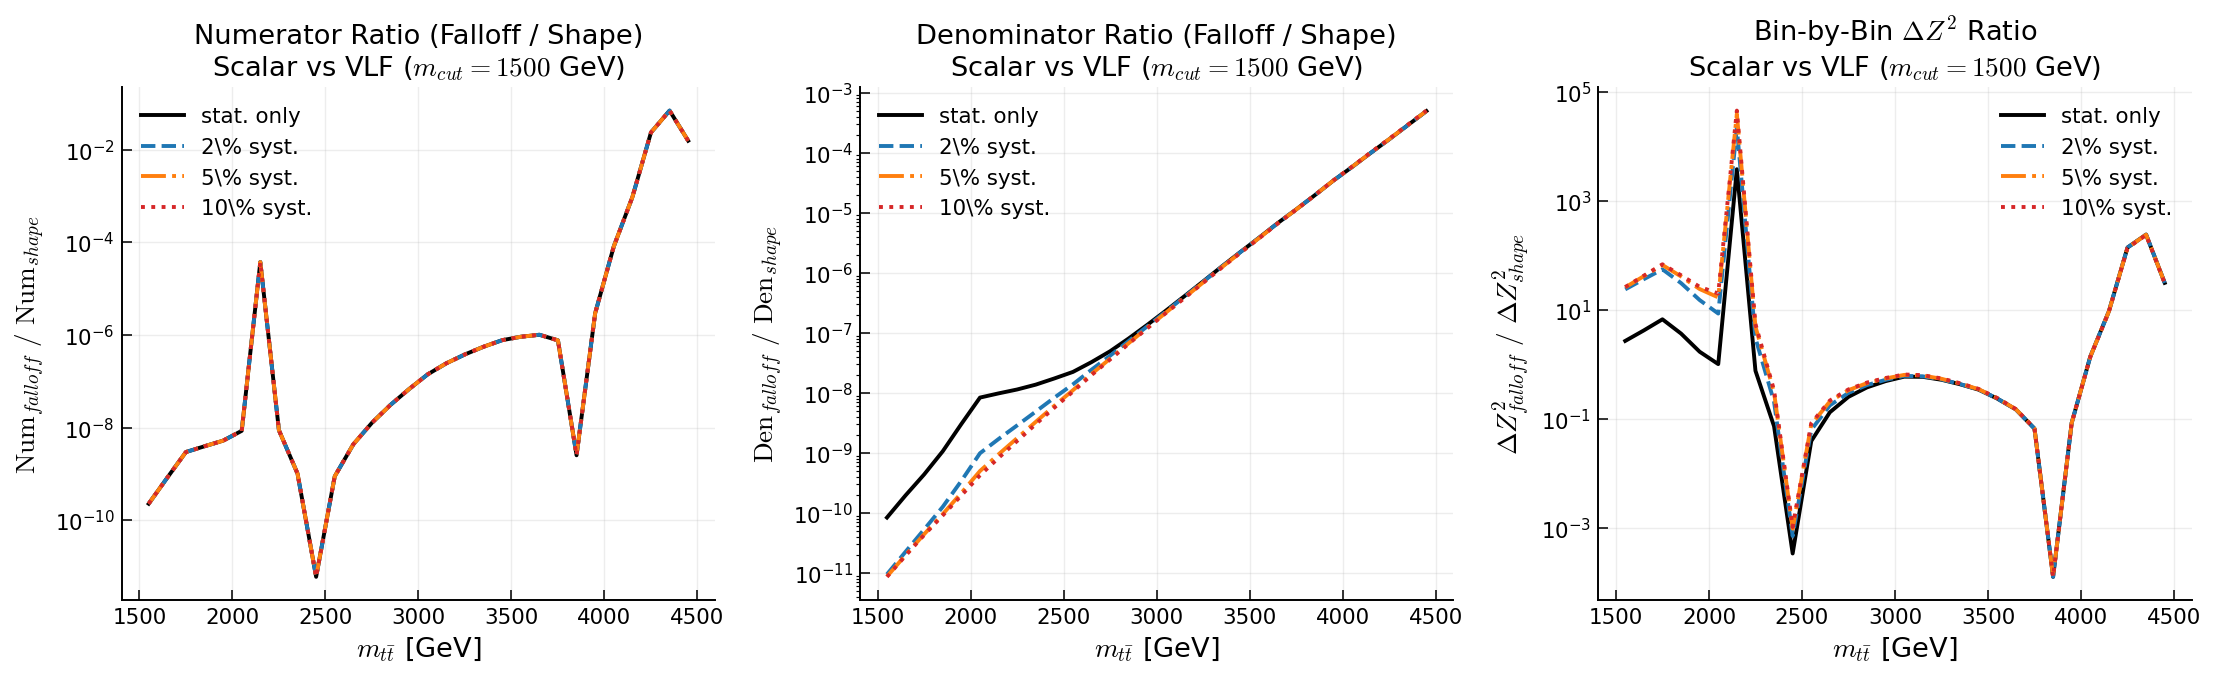

In [10]:
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
labels = ["Scalar", "VLF", "Zprime"]
var = "m_tt"

target_mcut = 1500
target_pair = 'Scalar vs VLF' # Select which pair you want to analyze

mcuts = [500, 1000, 1500, 1800, 2000, 2200, 2500, 3000]
bin_width = 100.0 # GeV
mcut_max = 4_500 # GeV
alpha = 1e-12
L_target = 500.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]


# ------------------------------------------------------------
#  Data Preparation & Main Loop
# ------------------------------------------------------------
df_sm_work = df_sm[[var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_sm_work = df_sm_work[df_sm_work[var] > 0]

df_hyp_work = df_bsm[["label", var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_work = df_hyp_work[df_hyp_work[var] > 0]

global_max = max(df_sm_work[var].max(), df_hyp_work[var].max())

component_store = {}

for mcut in mcuts:
    bin_edge_max = mcut_max if mcut_max is not None else global_max
    sm_mask = (df_sm_work[var] > mcut) & (df_sm_work[var] <= bin_edge_max)
    hyp_mask = (df_hyp_work[var] > mcut) & (df_hyp_work[var] <= bin_edge_max)

    df_sm_tail = df_sm_work[sm_mask].copy()
    df_hyp_tail = df_hyp_work[hyp_mask].copy()

    if len(df_sm_tail) == 0 or len(df_hyp_tail) == 0: continue

    bins = np.arange(mcut, bin_edge_max + bin_width, bin_width)


    h_sm_raw = hp.weighted_hist(df_sm_tail[var].values, df_sm_tail["weight"].values, bins)
    n_sm = h_sm_raw * L_target * 1000.0

    raw_templates = {}
    norm_templates = {}

    ok = True
    for lab in labels:
        sub = df_hyp_tail[df_hyp_tail["label"] == lab]
        if len(sub) == 0: ok = False; break

        h_raw = hp.weighted_hist(sub[var].values, sub["weight"].values, bins)
        delta = hp.build_signed_delta(h_raw, h_sm_raw, alpha=alpha)
        dnorm = hp.normalize_signed_template(delta, alpha=alpha)

        if dnorm is None: ok = False; break

        raw_templates[lab] = h_raw
        norm_templates[lab] = dnorm

    if not ok: continue

    # Cross-section alignment: Scale BSM templates to expected absolute yields
    ref_template = raw_templates['Zprime'].copy()
    for lab in raw_templates:
        raw_templates[lab] = hp.event_number_normalization(ref_template, raw_templates[lab], lum=L_target)

    for a, b in combinations(labels, 2):
        dA, dB = norm_templates[a], norm_templates[b]
        hA, hB = raw_templates[a], raw_templates[b]
        pair_name = f"{a} vs {b}"

        for eps in eps_values:
            Z_fa, num_fa, den_fa = hp.asimov_signed_Z_rigorous(dA, dB, hA, hB, n_sm, eps, alpha)
            _, num_sh, den_sh = hp.asimov_shape_Z_with_syst(hA, hB, frac_syst=eps, mode="avg", eps=alpha)

            # Store the underlying mathematical components for the target pair
            if mcut not in component_store: component_store[mcut] = {}
            if pair_name not in component_store[mcut]: component_store[mcut][pair_name] = {}

            component_store[mcut][pair_name][eps] = {
                "num_fa": num_fa, "den_fa": den_fa,
                "num_sh": num_sh, "den_sh": den_sh,
                "bins": bins
            }

# ------------------------------------------------------------
# Plotting Functions
# ------------------------------------------------------------
if target_mcut not in component_store or target_pair not in component_store[target_mcut]:
    print(f"Data not available for {target_pair} at {target_mcut} GeV.")
else:
    # ------------------------------------------------------------
    # PLOT A: Standard Shape Method Components
    # ------------------------------------------------------------
    fig_sh, axes_sh = plt.subplots(1, 3, figsize=(16, 5))

    for eps_syst in eps_values:
        if eps_syst not in component_store[target_mcut][target_pair]: continue
        comp = component_store[target_mcut][target_pair][eps_syst]
        b = comp["bins"]
        centers = 0.5 * (b[:-1] + b[1:])

        color, ls = syst_styles.get(eps_syst, ("black", "-"))
        label = "stat. only" if eps_syst == 0.0 else rf"{int(100*eps_syst)}\% syst."

        with np.errstate(divide='ignore', invalid='ignore'):
            z2_sh = np.nan_to_num(comp["num_sh"] / comp["den_sh"], posinf=0, neginf=0)

        axes_sh[0].plot(centers, comp["num_sh"], color=color, linestyle=ls, linewidth=2, label=label)
        axes_sh[1].plot(centers, comp["den_sh"], color=color, linestyle=ls, linewidth=2, label=label)
        axes_sh[2].plot(centers, z2_sh, color=color, linestyle=ls, linewidth=2, label=label)

    axes_sh[0].set_title("Standard Shape: Numerator")
    axes_sh[0].set_ylabel(r"$(n_A - n_B)^2$")
    axes_sh[0].set_yscale('log')

    axes_sh[1].set_title("Standard Shape: Denominator (Variance)")
    axes_sh[1].set_ylabel(r"$\sigma^2$")
    axes_sh[1].set_yscale('log')

    axes_sh[2].set_title(r"Standard Shape: Bin-by-Bin $\Delta Z^2$")
    axes_sh[2].set_ylabel(r"$\Delta Z^2_{shape}$ per bin")
    axes_sh[2].set_yscale('log')

    for ax in axes_sh:
        ax.set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")
        hp.beautify_axis(ax, grid=True)
        ax.legend(loc="best")

    fig_sh.suptitle(f"Standard Shape Method Components: {target_pair} ($m_{{cut}} = {target_mcut}$ GeV)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig('components_standard_shape.pdf', bbox_inches='tight')
    plt.show()

    # ------------------------------------------------------------
    # PLOT B: Normalized Falloff Method Components
    # ------------------------------------------------------------
    fig_fa, axes_fa = plt.subplots(1, 3, figsize=(16, 5))

    for eps_syst in eps_values:
        if eps_syst not in component_store[target_mcut][target_pair]: continue
        comp = component_store[target_mcut][target_pair][eps_syst]
        b = comp["bins"]
        centers = 0.5 * (b[:-1] + b[1:])

        color, ls = syst_styles.get(eps_syst, ("black", "-"))
        label = "stat. only" if eps_syst == 0.0 else rf"{int(100*eps_syst)}\% syst."

        with np.errstate(divide='ignore', invalid='ignore'):
            z2_fa = np.nan_to_num(comp["num_fa"] / comp["den_fa"], posinf=0, neginf=0)

        axes_fa[0].plot(centers, comp["num_fa"], color=color, linestyle=ls, linewidth=2, label=label)
        axes_fa[1].plot(centers, comp["den_fa"], color=color, linestyle=ls, linewidth=2, label=label)
        axes_fa[2].plot(centers, z2_fa, color=color, linestyle=ls, linewidth=2, label=label)

    axes_fa[0].set_title("Falloff Method: Numerator")
    axes_fa[0].set_ylabel(r"$(\widehat{\Delta}_A - \widehat{\Delta}_B)^2$")
    axes_fa[0].set_yscale('log')

    axes_fa[1].set_title("Falloff Method: Denominator (Variance)")
    axes_fa[1].set_ylabel(r"$\sigma_{ref}^2$")
    axes_fa[1].set_yscale('log')

    axes_fa[2].set_title(r"Falloff Method: Bin-by-Bin $\Delta Z^2$")
    axes_fa[2].set_ylabel(r"$\Delta Z^2_{falloff}$ per bin")
    axes_fa[2].set_yscale('log')

    for ax in axes_fa:
        ax.set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")
        hp.beautify_axis(ax, grid=True)
        ax.legend(loc="best")

    fig_fa.suptitle(f"Normalized Falloff Method Components: {target_pair} ($m_{{cut}} = {target_mcut}$ GeV)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig('components_falloff.pdf', bbox_inches='tight')
    plt.show()

    # ------------------------------------------------------------
    # PLOT C: 3-Panel Diagnostic Ratio Viewer (Falloff / Shape)
    # ------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for eps_syst in eps_values:
        if eps_syst not in component_store[target_mcut][target_pair]: continue

        comp = component_store[target_mcut][target_pair][eps_syst]
        b = comp["bins"]
        centers = 0.5 * (b[:-1] + b[1:])

        color, ls = syst_styles.get(eps_syst, ("black", "-"))
        label = "stat. only" if eps_syst == 0.0 else rf"{int(100*eps_syst)}\% syst."

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_num = np.nan_to_num(comp["num_fa"] / comp["num_sh"], posinf=0, neginf=0)
            ratio_den = np.nan_to_num(comp["den_fa"] / comp["den_sh"], posinf=0, neginf=0)
            ratio_z2  = np.nan_to_num((comp["num_fa"] / comp["den_fa"]) / (comp["num_sh"] / comp["den_sh"]), posinf=0, neginf=0)

        axes[0].plot(centers, ratio_num, color=color, linestyle=ls, linewidth=2, label=label)
        axes[1].plot(centers, ratio_den, color=color, linestyle=ls, linewidth=2, label=label)
        axes[2].plot(centers, ratio_z2, color=color, linestyle=ls, linewidth=2, label=label)

    axes[0].set_title(rf"Numerator Ratio (Falloff / Shape)" + f"\n{target_pair} ($m_{{cut}} = {target_mcut}$ GeV)")
    axes[0].set_ylabel(r"$ \text{Num}_{falloff} \ / \ \text{Num}_{shape}$")
    axes[0].set_yscale('log')
    hp.beautify_axis(axes[0], grid=True)
    axes[0].legend()

    axes[1].set_title(rf"Denominator Ratio (Falloff / Shape)" + f"\n{target_pair} ($m_{{cut}} = {target_mcut}$ GeV)")
    axes[1].set_ylabel(r"$ \text{Den}_{falloff} \ / \ \text{Den}_{shape}$")
    axes[1].set_yscale('log')
    hp.beautify_axis(axes[1], grid=True)
    axes[1].legend()

    axes[2].set_title(rf"Bin-by-Bin $\Delta Z^2$ Ratio" + f"\n{target_pair} ($m_{{cut}} = {target_mcut}$ GeV)")
    axes[2].set_ylabel(r"$ \Delta Z^2_{falloff} \ / \ \Delta Z^2_{shape} $")
    axes[2].set_yscale('log')
    hp.beautify_axis(axes[2], grid=True)
    axes[2].legend()

    for ax in axes:
        ax.set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")

    plt.tight_layout()
    plt.savefig('diagnostic_plot_ratio.pdf')
    plt.show()

## We can see that the Falloff method has a different behavior because of a dominance of statistical errors depending on the value of $\varepsilon$. To see it clearly, we can plot the variance of each method splitting the statistical and systematical contributions to it.
## We observe that the statistical variance in the fallof method dominates in the peak region for $\varepsilon = 2\%$, are of the same order in the peak region for $\varepsilon = 5\%$ an it is subdominant for $\varepsilon = 10\%$.
## In the shape method the statistical variance dominates only for $m_{t\bar{t}}\simeq 2750, \,3000 \text{ and }4000$ GeV for $\varepsilon= 2\%, \,5\% \text{ and }10\%$, respectively.
## There for, while the variance of the shape always increase with the systematical error in the region of the peak, the falloff variance barely change for $\varepsilon = 2\%$ and $5\%$ around the peak. Also, the dominance of the statistical error at the tail, in the fallof method, occurs a little bit later than the shape.

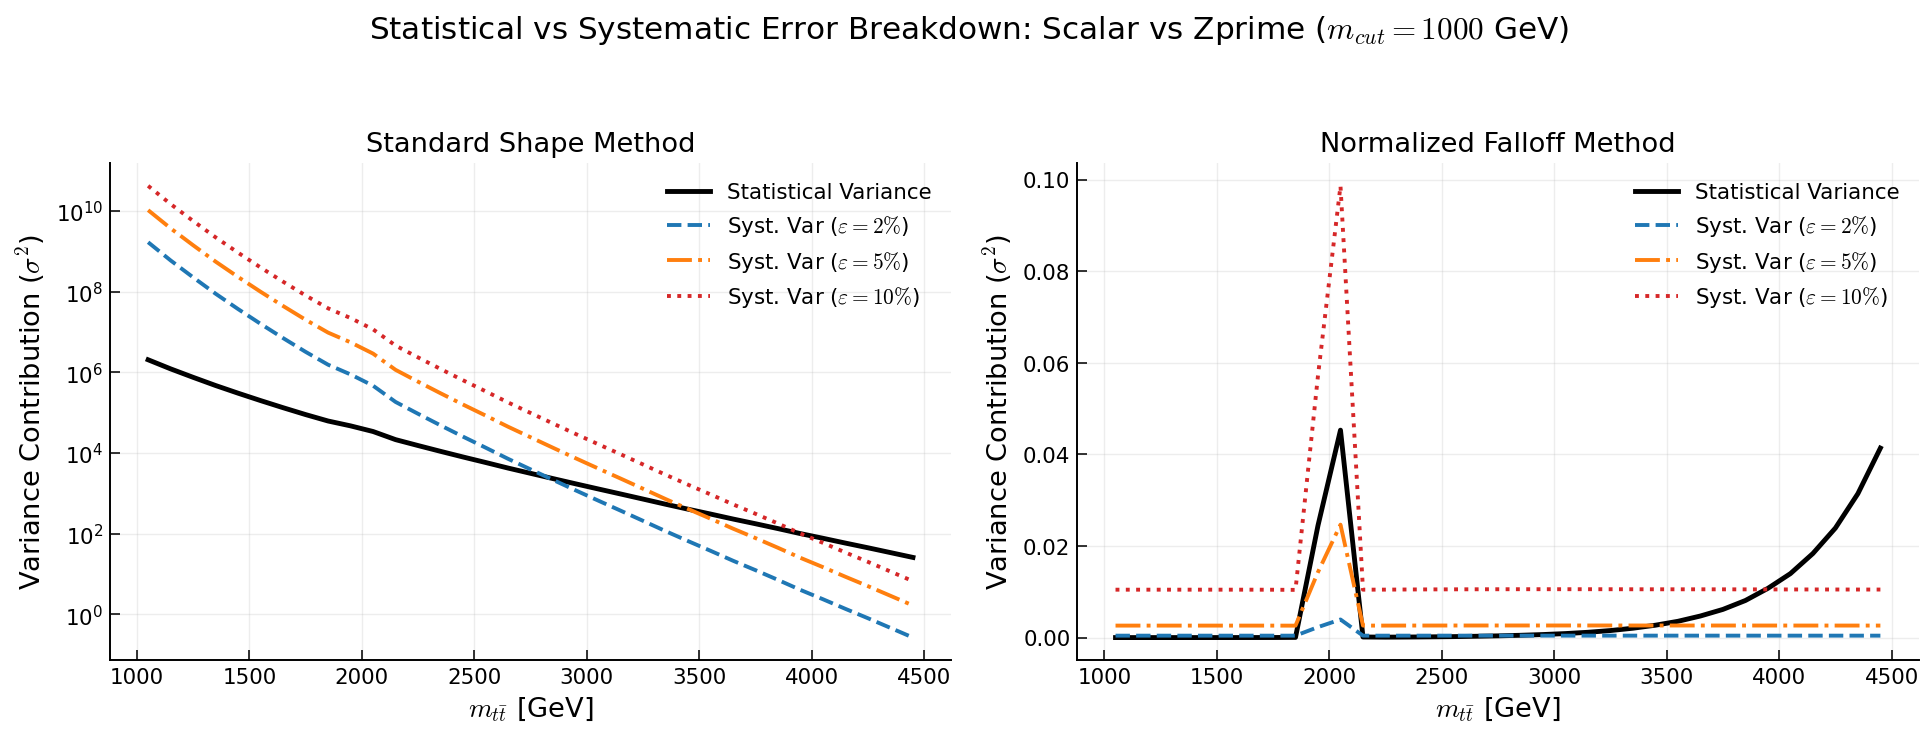

In [11]:

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
labels = ["Scalar", "VLF", "Zprime"]
var = "m_tt"

target_mcut = 1000 # Focus on 1000 GeV for the diagnostic plot
mcuts = [1000]
bin_width = 100.0 # GeV
mcut_max = 4_500
alpha = 1e-12

L_target = 500.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# Valid options: "Scalar vs VLF", "Scalar vs Zprime", "VLF vs Zprime"
best_pair = "Scalar vs Zprime"

outdir = Path("paper_plots_systematics")
outdir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Data Preparation & Main Loop
# ------------------------------------------------------------
df_sm_work = df_sm[[var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_sm_work = df_sm_work[df_sm_work[var] > 0]

df_hyp_work = df_bsm[["label", var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_work = df_hyp_work[df_hyp_work[var] > 0]

global_max = max(df_sm_work[var].max(), df_hyp_work[var].max())

component_store = {}

for mcut in mcuts:
    bin_edge_max = mcut_max if mcut_max is not None else global_max
    sm_mask = (df_sm_work[var] > mcut) & (df_sm_work[var] <= bin_edge_max)
    hyp_mask = (df_hyp_work[var] > mcut) & (df_hyp_work[var] <= bin_edge_max)

    df_sm_tail = df_sm_work[sm_mask].copy()
    df_hyp_tail = df_hyp_work[hyp_mask].copy()

    if len(df_sm_tail) == 0 or len(df_hyp_tail) == 0: continue

    bins = np.arange(mcut, bin_edge_max + bin_width, bin_width)

    # Generate Physical SM Yields directly
    h_sm_raw = hp.weighted_hist(df_sm_tail[var].values, df_sm_tail["weight"].values, bins)
    n_sm = h_sm_raw * L_target * 1000.0

    raw_templates = {}
    norm_templates = {}

    ok = True
    for lab in labels:
        sub = df_hyp_tail[df_hyp_tail["label"] == lab]
        if len(sub) == 0: ok = False; break

        h_raw = hp.weighted_hist(sub[var].values, sub["weight"].values, bins)
        delta = hp.build_signed_delta(h_raw, h_sm_raw, alpha=alpha)
        dnorm = hp.normalize_signed_template(delta, alpha=alpha)

        if dnorm is None: ok = False; break

        raw_templates[lab] = h_raw
        norm_templates[lab] = dnorm

    if not ok: continue

    # Cross-section alignment: Scale BSM templates to expected absolute yields
    ref_template = raw_templates['Zprime'].copy()
    for lab in raw_templates:
        raw_templates[lab] = hp.event_number_normalization(ref_template, raw_templates[lab], lum=L_target)

    for a, b in combinations(labels, 2):
        dA, dB = norm_templates[a], norm_templates[b]
        hA, hB = raw_templates[a], raw_templates[b]
        pair_name = f"{a} vs {b}"

        for eps in eps_values:
            # Pass absolute n_sm to rigorous Falloff math
            Z_fa, num_fa, den_fa = hp.asimov_signed_Z_rigorous(dA, dB, hA, hB, n_sm, eps, alpha)
            _, num_sh, den_sh = hp.asimov_shape_Z_with_syst(hA, hB, frac_syst=eps, mode="avg", eps=alpha)

            if mcut not in component_store: component_store[mcut] = {}
            if pair_name not in component_store[mcut]: component_store[mcut][pair_name] = {}

            component_store[mcut][pair_name][eps] = {
                "num_fa": num_fa, "den_fa": den_fa,
                "num_sh": num_sh, "den_sh": den_sh,
                "bins": bins
            }

# ------------------------------------------------------------
# Statistical vs Systematic Breakdown
# ------------------------------------------------------------


    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

    stat_comp = component_store[target_mcut][best_pair][0.0]
    stat_sh = stat_comp["den_sh"]
    stat_fa = stat_comp["den_fa"]
    b = stat_comp["bins"]
    centers = 0.5 * (b[:-1] + b[1:])

    # --- Panel 1: Standard Shape Method ---
    axes2[0].plot(centers, stat_sh, color="black", linestyle="-", linewidth=2.5, label="Statistical Variance")

    for eps_syst in eps_values:
        if eps_syst == 0.0: continue
        comp = component_store[target_mcut][best_pair][eps_syst]
        syst_sh = np.maximum(comp["den_sh"] - stat_sh, 1e-15)

        color, ls = syst_styles.get(eps_syst, ("black", "--"))
        axes2[0].plot(centers, syst_sh, color=color, linestyle=ls, linewidth=2,
                      label=rf"Syst. Var ($\varepsilon = {int(100*eps_syst)}\%$)")

    axes2[0].set_title("Standard Shape Method")
    axes2[0].set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")
    axes2[0].set_ylabel(r"Variance Contribution ($\sigma^2$)")
    axes2[0].set_yscale('log')
    hp.beautify_axis(axes2[0], grid=True)
    axes2[0].legend(loc="best")

    # --- Panel 2: Normalized Falloff Method ---
    axes2[1].plot(centers, stat_fa, color="black", linestyle="-", linewidth=2.5, label="Statistical Variance")

    for eps_syst in eps_values:
        if eps_syst == 0.0: continue
        comp = component_store[target_mcut][best_pair][eps_syst]
        syst_fa = np.maximum(comp["den_fa"] - stat_fa, 1e-15)

        color, ls = syst_styles.get(eps_syst, ("black", "--"))
        axes2[1].plot(centers, syst_fa, color=color, linestyle=ls, linewidth=2,
                      label=rf"Syst. Var ($\varepsilon = {int(100*eps_syst)}\%$)")

    axes2[1].set_title("Normalized Falloff Method")
    axes2[1].set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")
    axes2[1].set_ylabel(r"Variance Contribution ($\sigma^2$)")
    hp.beautify_axis(axes2[1], grid=True)
    axes2[1].legend(loc="best")

    fig2.suptitle(f"Statistical vs Systematic Error Breakdown: {best_pair} ($m_{{cut}} = {target_mcut}$ GeV)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig(outdir / 'diagnostic_plot_stat_vs_syst.pdf', bbox_inches="tight")
    plt.show()

In [12]:

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
labels = ["Scalar", "VLF", "Zprime"]
var = "m_tt"

target_pair = 'Scalar vs VLF'  # Select which pair you want to analyze
target_eps = 0.05              # Choose 0.0, 0.02, 0.05, or 0.10

mcuts = [500, 1000, 1500, 1800, 2000, 2200, 2500, 3000]
bin_width = 100.0 # GeV
mcut_max = 4_500  # GeV
alpha = 1e-12
L_target = 500.0  # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# ------------------------------------------------------------
# Data Preparation & Main Loop (With Diagnostics)
# ------------------------------------------------------------
df_sm_work = df_sm[[var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_sm_work = df_sm_work[df_sm_work[var] > 0]

df_hyp_work = df_bsm[["label", var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_work = df_hyp_work[df_hyp_work[var] > 0]

global_max = max(df_sm_work[var].max(), df_hyp_work[var].max())

component_store = {}

for mcut in mcuts:
    bin_edge_max = mcut_max if mcut_max is not None else global_max
    sm_mask = (df_sm_work[var] > mcut) & (df_sm_work[var] <= bin_edge_max)
    hyp_mask = (df_hyp_work[var] > mcut) & (df_hyp_work[var] <= bin_edge_max)

    df_sm_tail = df_sm_work[sm_mask].copy()
    df_hyp_tail = df_hyp_work[hyp_mask].copy()

    if len(df_sm_tail) == 0:
        print(f"[FAIL] mcut = {mcut:4d} GeV | Reason: 0 SM background events left.")
        continue
    if len(df_hyp_tail) == 0:
        print(f"[FAIL] mcut = {mcut:4d} GeV | Reason: 0 BSM signal events left.")
        continue

    bins = np.arange(mcut, bin_edge_max + bin_width, bin_width)

    h_sm_raw = hp.weighted_hist(df_sm_tail[var].values, df_sm_tail["weight"].values, bins)
    n_sm = h_sm_raw * L_target * 1000.0

    raw_templates = {}
    norm_templates = {}

    ok = True
    for lab in labels:
        sub = df_hyp_tail[df_hyp_tail["label"] == lab]
        if len(sub) == 0:
            print(f"[FAIL] mcut = {mcut:4d} GeV | Reason: Model '{lab}' has 0 events surviving this cut.")
            ok = False; break

        h_raw = hp.weighted_hist(sub[var].values, sub["weight"].values, bins)
        delta = hp.build_signed_delta(h_raw, h_sm_raw, alpha=alpha)
        dnorm = hp.normalize_signed_template(delta, alpha=alpha)

        if dnorm is None:
            print(f"[FAIL] mcut = {mcut:4d} GeV | Reason: hp.normalize_signed_template failed for '{lab}'.")
            ok = False; break

        raw_templates[lab] = h_raw
        norm_templates[lab] = dnorm

    if not ok: continue

    # Cross-section alignment: Scale BSM templates to expected absolute yields
    ref_template = raw_templates['Scalar'].copy()
    for lab in raw_templates:
        raw_templates[lab] = hp.event_number_normalization(ref_template, raw_templates[lab], lum=L_target)

    for a, b in combinations(labels, 2):
        dA, dB = norm_templates[a], norm_templates[b]
        hA, hB = raw_templates[a], raw_templates[b]
        pair_name = f"{a} vs {b}"

        for eps in eps_values:
            Z_fa, num_fa, den_fa = hp.asimov_signed_Z_rigorous(dA, dB, hA, hB, n_sm, eps, alpha)
            _, num_sh, den_sh = hp.asimov_shape_Z_with_syst(hA, hB, frac_syst=eps, mode="avg", eps=alpha)

            if mcut not in component_store: component_store[mcut] = {}
            if pair_name not in component_store[mcut]: component_store[mcut][pair_name] = {}

            component_store[mcut][pair_name][eps] = {
                "num_fa": num_fa, "den_fa": den_fa,
                "num_sh": num_sh, "den_sh": den_sh,
                "bins": bins
            }



Plotting Scalar vs VLF at eps=0.05 for m_cuts: [500, 1000, 1500, 1800, 2000, 2200, 2500, 3000]


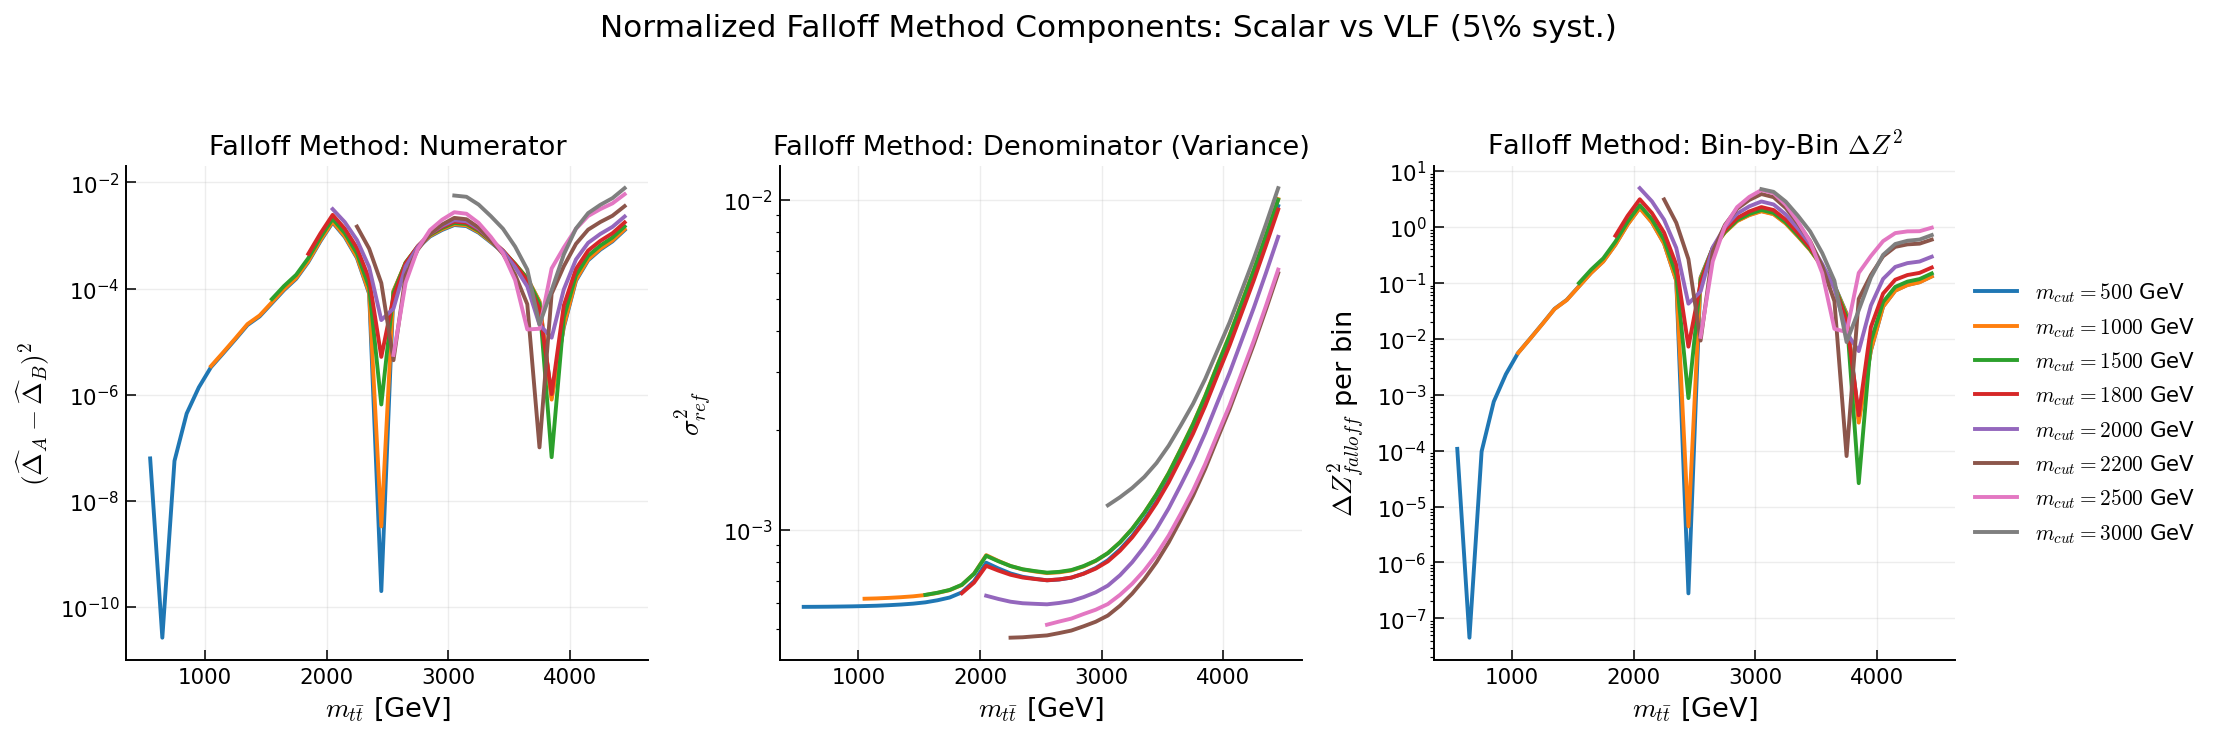

In [13]:


# ------------------------------------------------------------
# Plotting: Normalized Falloff Method Components vs m_cut
# ------------------------------------------------------------
colors = plt.get_cmap('tab10').colors

eps_label_str = "stat. only" if target_eps == 0.0 else rf"{int(100*target_eps)}\% syst."

# Verify data exists for the selected pair and systematic
valid_mcuts = [m for m in mcuts if m in component_store and target_pair in component_store[m] and target_eps in component_store[m][target_pair]]

if not valid_mcuts:
    print(f"[PLOT FAILED] Data not available for {target_pair} at eps = {target_eps}.")
    print("Check the diagnostic output above to see which mcuts failed.")
else:
    print(f"Plotting {target_pair} at eps={target_eps} for m_cuts: {valid_mcuts}")
    fig_fa, axes_fa = plt.subplots(1, 3, figsize=(16, 5))

    for i, mcut in enumerate(valid_mcuts):
        comp = component_store[mcut][target_pair][target_eps]
        b = comp["bins"]
        centers = 0.5 * (b[:-1] + b[1:])

        # We find the original index of the mcut so the colors remain consistent
        color_idx = mcuts.index(mcut)
        # Use modulo just in case you ever add more than 10 mcuts to your list
        color = colors[color_idx % len(colors)]
        label = rf"$m_{{cut}} = {mcut}$ GeV"

        # ... (The rest of the plotting code remains exactly the same) ...

        # Calculate bin-by-bin Delta Z^2 for the falloff method
        with np.errstate(divide='ignore', invalid='ignore'):
            z2_fa = np.nan_to_num(comp["num_fa"] / comp["den_fa"], posinf=0, neginf=0)

        axes_fa[0].plot(centers, comp["num_fa"], color=color, linewidth=2, label=label)
        axes_fa[1].plot(centers, comp["den_fa"], color=color, linewidth=2, label=label)
        axes_fa[2].plot(centers, z2_fa, color=color, linewidth=2, label=label)

    # Numerator Formatting
    axes_fa[0].set_title("Falloff Method: Numerator")
    axes_fa[0].set_ylabel(r"$(\widehat{\Delta}_A - \widehat{\Delta}_B)^2$")
    axes_fa[0].set_yscale('log')

    # Denominator Formatting
    axes_fa[1].set_title("Falloff Method: Denominator (Variance)")
    axes_fa[1].set_ylabel(r"$\sigma_{ref}^2$")
    axes_fa[1].set_yscale('log')

    # Delta Z^2 Formatting
    axes_fa[2].set_title(r"Falloff Method: Bin-by-Bin $\Delta Z^2$")
    axes_fa[2].set_ylabel(r"$\Delta Z^2_{falloff}$ per bin")
    axes_fa[2].set_yscale('log')

    # General Formatting for all subplots
    for ax in axes_fa:
        ax.set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")
        if hasattr(hp, 'beautify_axis'):
            hp.beautify_axis(ax, grid=True)
        else:
            ax.grid(True, linestyle='--', alpha=0.7)

    # Place legend outside the last plot
    axes_fa[-1].legend(loc="center left", bbox_to_anchor=(1, 0.5))

    fig_fa.suptitle(f"Normalized Falloff Method Components: {target_pair} ({eps_label_str})", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig('components_falloff_mcut_scan.pdf', bbox_inches='tight')
    plt.show()

Plotting Scalar vs Zprime (Shape Method) at eps=0.05 for m_cuts: [500, 1000, 1500, 1800, 2000, 2200, 2500, 3000]


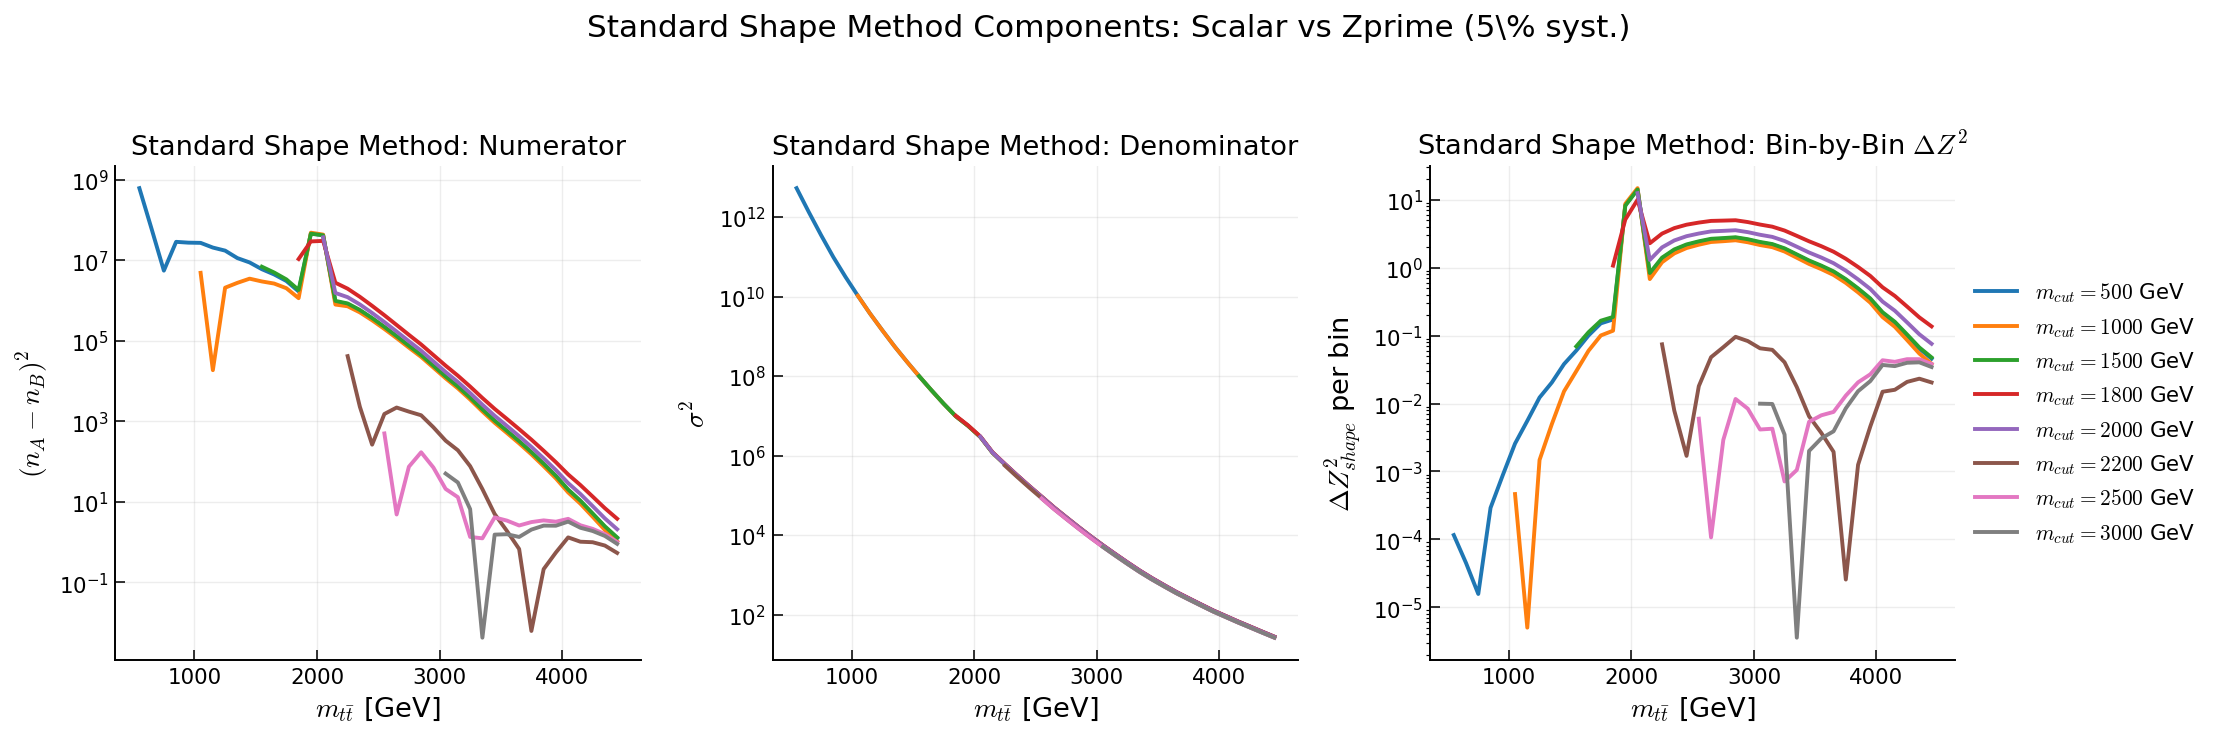

In [14]:


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
labels = ["Scalar", "VLF", "Zprime"]
var = "m_tt"

target_pair = 'Scalar vs Zprime'  # Select which pair you want to analyze
target_eps = 0.05              # Choose 0.0, 0.02, 0.05, or 0.10

mcuts = [500, 1000, 1500, 1800, 2000, 2200, 2500, 3000]
bin_width = 100.0 # GeV
mcut_max = 4_500  # GeV
alpha = 1e-12
L_target = 500.0  # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# ------------------------------------------------------------
# Data Preparation & Main Loop (With Diagnostics)
# ------------------------------------------------------------
df_sm_work = df_sm[[var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_sm_work = df_sm_work[df_sm_work[var] > 0]

df_hyp_work = df_bsm[["label", var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_work = df_hyp_work[df_hyp_work[var] > 0]

global_max = max(df_sm_work[var].max(), df_hyp_work[var].max())

component_store = {}


for mcut in mcuts:
    bin_edge_max = mcut_max if mcut_max is not None else global_max
    sm_mask = (df_sm_work[var] > mcut) & (df_sm_work[var] <= bin_edge_max)
    hyp_mask = (df_hyp_work[var] > mcut) & (df_hyp_work[var] <= bin_edge_max)

    df_sm_tail = df_sm_work[sm_mask].copy()
    df_hyp_tail = df_hyp_work[hyp_mask].copy()

    if len(df_sm_tail) == 0:
        print(f"[FAIL] mcut = {mcut:4d} GeV | Reason: 0 SM background events left.")
        continue
    if len(df_hyp_tail) == 0:
        print(f"[FAIL] mcut = {mcut:4d} GeV | Reason: 0 BSM signal events left.")
        continue

    bins = np.arange(mcut, bin_edge_max + bin_width, bin_width)

    h_sm_raw = hp.weighted_hist(df_sm_tail[var].values, df_sm_tail["weight"].values, bins)
    n_sm = h_sm_raw * L_target * 1000.0

    raw_templates = {}
    norm_templates = {}

    ok = True
    for lab in labels:
        sub = df_hyp_tail[df_hyp_tail["label"] == lab]
        if len(sub) == 0:
            print(f"[FAIL] mcut = {mcut:4d} GeV | Reason: Model '{lab}' has 0 events surviving this cut.")
            ok = False; break

        h_raw = hp.weighted_hist(sub[var].values, sub["weight"].values, bins)
        delta = hp.build_signed_delta(h_raw, h_sm_raw, alpha=alpha)
        dnorm = hp.normalize_signed_template(delta, alpha=alpha)

        if dnorm is None:
            print(f"[FAIL] mcut = {mcut:4d} GeV | Reason: hp.normalize_signed_template failed for '{lab}'.")
            ok = False; break

        raw_templates[lab] = h_raw
        norm_templates[lab] = dnorm

    if not ok: continue

    # Cross-section alignment: Scale BSM templates to expected absolute yields
    ref_template = raw_templates['Zprime'].copy()
    for lab in raw_templates:
        raw_templates[lab] = hp.event_number_normalization(ref_template, raw_templates[lab], lum=L_target)

    for a, b in combinations(labels, 2):
        dA, dB = norm_templates[a], norm_templates[b]
        hA, hB = raw_templates[a], raw_templates[b]
        pair_name = f"{a} vs {b}"

        for eps in eps_values:
            Z_fa, num_fa, den_fa = hp.asimov_signed_Z_rigorous(dA, dB, hA, hB, n_sm, eps, alpha)
            _, num_sh, den_sh = hp.asimov_shape_Z_with_syst(hA, hB, frac_syst=eps, mode="avg", eps=alpha)

            if mcut not in component_store: component_store[mcut] = {}
            if pair_name not in component_store[mcut]: component_store[mcut][pair_name] = {}

            component_store[mcut][pair_name][eps] = {
                "num_fa": num_fa, "den_fa": den_fa,
                "num_sh": num_sh, "den_sh": den_sh,
                "bins": bins
            }



# ------------------------------------------------------------
# Plotting: Standard Shape Method Components vs m_cut
# ------------------------------------------------------------

colors = plt.get_cmap('tab10').colors

eps_label_str = "stat. only" if target_eps == 0.0 else rf"{int(100*target_eps)}\% syst."

# Verify data exists for the selected pair and systematic
valid_mcuts = [m for m in mcuts if m in component_store and target_pair in component_store[m] and target_eps in component_store[m][target_pair]]

if not valid_mcuts:
    print(f"[PLOT FAILED] Data not available for {target_pair} at eps = {target_eps}.")
    print("Check the diagnostic output above to see which mcuts failed.")
else:
    print(f"Plotting {target_pair} (Shape Method) at eps={target_eps} for m_cuts: {valid_mcuts}")
    fig_sh, axes_sh = plt.subplots(1, 3, figsize=(16, 5))

    for i, mcut in enumerate(valid_mcuts):
        comp = component_store[mcut][target_pair][target_eps]
        b = comp["bins"]
        centers = 0.5 * (b[:-1] + b[1:])

        # We find the original index of the mcut so the colors remain consistent
        color_idx = mcuts.index(mcut)
        color = colors[color_idx % len(colors)]
        label = rf"$m_{{cut}} = {mcut}$ GeV"

        # Calculate bin-by-bin Delta Z^2 for the standard shape method
        with np.errstate(divide='ignore', invalid='ignore'):
            z2_sh = np.nan_to_num(comp["num_sh"] / comp["den_sh"], posinf=0, neginf=0)

        axes_sh[0].plot(centers, comp["num_sh"], color=color, linewidth=2, label=label)
        axes_sh[1].plot(centers, comp["den_sh"], color=color, linewidth=2, label=label)
        axes_sh[2].plot(centers, z2_sh, color=color, linewidth=2, label=label)

    # Numerator Formatting
    axes_sh[0].set_title("Standard Shape Method: Numerator")
    axes_sh[0].set_ylabel(r"$(n_A - n_B)^2$")
    axes_sh[0].set_yscale('log')

    # Denominator Formatting
    axes_sh[1].set_title("Standard Shape Method: Denominator")
    axes_sh[1].set_ylabel(r"$\sigma^2$")
    axes_sh[1].set_yscale('log')

    # Delta Z^2 Formatting
    axes_sh[2].set_title(r"Standard Shape Method: Bin-by-Bin $\Delta Z^2$")
    axes_sh[2].set_ylabel(r"$\Delta Z^2_{shape}$ per bin")
    axes_sh[2].set_yscale('log')

    # General Formatting for all subplots
    for ax in axes_sh:
        ax.set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")
        if hasattr(hp, 'beautify_axis'):
            hp.beautify_axis(ax, grid=True)
        else:
            ax.grid(True, linestyle='--', alpha=0.7)

    # Place legend outside the last plot
    axes_sh[-1].legend(loc="center left", bbox_to_anchor=(1, 0.5))

    fig_sh.suptitle(f"Standard Shape Method Components: {target_pair} ({eps_label_str})", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig('components_shape_mcut_scan.pdf', bbox_inches='tight')
    plt.show()